# Análise do Mini Índice WIN com foco em Gap

- gap de abertura;
- comportamento intraday após o gap;
- influência da janela de pré-close do dia anterior;
- criação de tabelas derivadas para análise estatística e machine learning.

- Qual a frequência de gap positivo e negativo?
- Quando o gap costuma fechar?
- O comportamento dos últimos 15 minutos do pregão anterior ajuda a prever o dia seguinte?
- Quais features fazem sentido para modelos supervisionados sem lookahead bias?


## 1. Configuração do estudo

Nesta etapa definimos os parâmetros principais do notebook: caminho do arquivo, tamanho da janela de pré-close, janelas de fill, bins de gap e horizontes de retorno.

Leitura rápida dos parâmetros:

- `JANELA_ATR = 14`: usa os últimos 14 dias para calcular o ATR médio.
- `JANELAS_FORWARD = [5, 15, 30]`: mede o retorno do preço 5, 15 e 30 minutos após a abertura.
- `JANELAS_FILL = [5, 10, 20, 30]`: mede se o gap fechou até 5, 10, 20 ou 30 minutos após a abertura.
- `ALVOS_ALPHA = [0.3, 0.5, 0.7, 1.0]`: cria alvos de fill parcial em 30%, 50%, 70% e 100% do gap.
- `BINS_GAP = [...]`: separa os gaps em faixas para resumir estatísticas.
- `MINIMO_LINHAS_TREINO = 150`: evita treinar modelo com pouca amostra.
- `np.inf`: significa infinito. Aqui ele serve para criar uma faixa sem limite, por exemplo `200 até infinito`.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)
plt.style.use('ggplot')

In [2]:
# Habilita tabelas interativas para todos os DataFrames do Pandas no Colab
# Aumentamos o max_columns para suportar a tabela de gaps que possui 29 colunas

# Configura o limite de colunas para as tabelas interativas

print("Tabelas interativas habilitadas (Limite: 50 colunas). Execute as células de visualização abaixo.")

Tabelas interativas habilitadas (Limite: 50 colunas). Execute as células de visualização abaixo.


In [3]:
# ─── CAMINHO DOS DADOS ───
CAMINHO_DADOS = 'https://raw.githubusercontent.com/rodrigoalves022/Topicos/Projetos/WIN%24N_M1.csv'

# CAMINHO_DADOS = Path('WIN$N_M1.csv')

# Pasta onde as bases derivadas serão salvas.
PASTA_SAIDA = Path('outputs_gap_win')
PASTA_SAIDA.mkdir(exist_ok=True)

# Quantidade de minutos usados para resumir o final do pregão anterior.
MINUTOS_PRECLOSE = 15

# Janela do ATR diário. ATR é uma medida média de amplitude/volatilidade.
JANELA_ATR = 14

# Retornos futuros medidos a partir da abertura do dia.
JANELAS_FORWARD = [5, 15, 30]

# Janelas máximas para considerar que o gap fechou em um trade intraday.
JANELAS_FILL = [5, 10, 15, 20, 30]

# Percentuais do gap que serão usados como alvos parciais de fill.
ALVOS_ALPHA = [0.3, 0.5, 0.7, 1.0]

# Faixas de gap em pontos. np.inf significa infinito.
BINS_GAP = [-np.inf, -200, -150, -100, -50, 0, 50, 100, 150, 200, np.inf]

# Quantidade mínima de linhas para aceitar o treino do modelo.
MINIMO_LINHAS_TREINO = 150

print(f'Arquivo/Url configurado: {CAMINHO_DADOS.resolve() if isinstance(CAMINHO_DADOS, Path) else CAMINHO_DADOS}')
print(f'Pasta de saída: {PASTA_SAIDA.resolve()}')


Arquivo/Url configurado: https://raw.githubusercontent.com/rodrigoalves022/Topicos/Projetos/WIN%24N_M1.csv
Pasta de saída: C:\Users\rodrigo.silva\Pictures\UFG\DB FIN\outputs_gap_win


## 2. Importação e padronização da base intraday

O arquivo veio no formato exportado de plataforma de mercado, com colunas entre `<>` e separação por tabulação. Aqui nós:

- lemos a base corretamente com `sep='\t'`;
- renomeamos as colunas para nomes limpos;
- criamos o `datetime`;
- ordenamos temporalmente;
- validamos duplicidades e dados faltantes.


In [4]:
# O arquivo está separado por tabulação. Por isso usamos sep='\t'.
dados_brutos = pd.read_csv(CAMINHO_DADOS, sep='	')
dados_brutos.columns = [coluna.strip('<>').lower() for coluna in dados_brutos.columns]

# Padronizamos alguns nomes para deixar as colunas mais legíveis.
mapa_renomeacao = {
    'tickvol': 'tick_volume',
    'vol': 'volume',
    'spread': 'spread'
}
dados_brutos = dados_brutos.rename(columns=mapa_renomeacao)

base_intraday = dados_brutos.copy()

# Junta data e hora em uma única coluna temporal.
base_intraday['datetime'] = pd.to_datetime(
    base_intraday['date'] + ' ' + base_intraday['time'],
    format='%Y.%m.%d %H:%M:%S'
)
base_intraday = base_intraday.sort_values('datetime').reset_index(drop=True)

colunas_preco = ['open', 'high', 'low', 'close']
colunas_auxiliares = ['tick_volume', 'volume', 'spread']

# Garante que as colunas numéricas realmente sejam tratadas como números.
for coluna in colunas_preco + colunas_auxiliares:
    base_intraday[coluna] = pd.to_numeric(base_intraday[coluna], errors='coerce')

# session_date representa o dia de pregão sem a parte do horário.
base_intraday['session_date'] = base_intraday['datetime'].dt.normalize()
base_intraday['clock_time'] = base_intraday['datetime'].dt.time
base_intraday['minute'] = base_intraday['datetime'].dt.hour * 60 + base_intraday['datetime'].dt.minute

print('Shape intraday:', base_intraday.shape)
print('Período:', base_intraday['datetime'].min(), '->', base_intraday['datetime'].max())
print('Duplicidades de datetime:', base_intraday['datetime'].duplicated().sum())
print('Valores nulos principais:')
print(base_intraday[colunas_preco + colunas_auxiliares].isna().sum())

base_intraday.head()


Shape intraday: (328762, 13)
Período: 2020-10-15 11:49:00 -> 2023-04-19 17:54:00
Duplicidades de datetime: 0
Valores nulos principais:
open           0
high           0
low            0
close          0
tick_volume    0
volume         0
spread         0
dtype: int64


,date,time,open,high,low,close,tick_volume,volume,spread,datetime,session_date,clock_time,minute
0,2020.10.15,11:49:00,98565,98575,98530,98575,2373,9001,5,2020-10-15 11:49:00,2020-10-15,11:49:00,709
1,2020.10.15,11:50:00,98570,98625,98570,98600,5483,19111,5,2020-10-15 11:50:00,2020-10-15,11:50:00,710
2,2020.10.15,11:51:00,98595,98600,98535,98580,4572,17663,5,2020-10-15 11:51:00,2020-10-15,11:51:00,711
3,2020.10.15,11:52:00,98575,98620,98535,98615,3536,13143,5,2020-10-15 11:52:00,2020-10-15,11:52:00,712
4,2020.10.15,11:53:00,98620,98625,98575,98610,3729,13702,5,2020-10-15 11:53:00,2020-10-15,11:53:00,713


## 3. Sanidade temporal do pregão

Nem todo dia tem o mesmo número de barras. Isso pode ocorrer por horário estendido, mudanças de sessão, início parcial da amostra ou dias especiais. Antes de modelar qualquer coisa, conferimos a estrutura diária para evitar assumir horários fixos incorretos.


In [5]:
# Esta tabela ajuda a entender a estrutura de cada sessão.
agenda_diaria = (
    base_intraday.groupby('session_date')
    .agg(
        primeira_barra=('datetime', 'min'),
        ultima_barra=('datetime', 'max'),
        quantidade_barras=('datetime', 'size')
    )
    .assign(
        horario_abertura=lambda df: df['primeira_barra'].dt.strftime('%H:%M:%S'),
        horario_fechamento=lambda df: df['ultima_barra'].dt.strftime('%H:%M:%S')
    )
)

print('Quantidade de dias:', len(agenda_diaria))
print()
print('Distribuição de barras por dia:')
print(agenda_diaria['quantidade_barras'].describe())
print()
print('Horários de fechamento mais comuns:')
print(agenda_diaria['horario_fechamento'].value_counts().head(10))

agenda_diaria.head()


Quantidade de dias: 603

Distribuição de barras por dia:
count    603.000000
mean     545.210614
std       23.247557
min      325.000000
25%      535.000000
50%      535.000000
75%      565.000000
max      566.000000
Name: quantidade_barras, dtype: float64

Horários de fechamento mais comuns:
horario_fechamento
17:54:00    354
18:24:00    244
17:55:00      2
18:31:00      2
18:01:00      1
Name: count, dtype: int64


,primeira_barra,ultima_barra,quantidade_barras,horario_abertura,horario_fechamento
session_date,,,,,
2020-10-15,2020-10-15 11:49:00,2020-10-15 17:54:00,366,11:49:00,17:54:00
2020-10-16,2020-10-16 09:00:00,2020-10-16 17:54:00,535,09:00:00,17:54:00
2020-10-19,2020-10-19 09:00:00,2020-10-19 17:54:00,535,09:00:00,17:54:00
2020-10-20,2020-10-20 09:00:00,2020-10-20 17:54:00,535,09:00:00,17:54:00
2020-10-21,2020-10-21 09:00:00,2020-10-21 17:54:00,535,09:00:00,17:54:00


## 4. Funções auxiliares

As próximas análises exigem medidas que não vêm prontas do CSV, como tempo até o fill, fill por janela de tempo, retornos futuros após a abertura e métricas de excursão (`MFE` e `MAE`).

Leitura em português:

- `MFE` = excursão favorável máxima;
- `MAE` = excursão adversa máxima;
- retornos "forward" = retornos medidos alguns minutos depois da abertura;
- fill temporal = verificar se o gap fechou dentro de uma janela, como 5, 10, 20 ou 30 minutos.

Essas funções existem para evitar repetição de código e deixar a lógica mais fácil de revisar.


In [6]:
def primeiro_horario_que_bate(day_frame, condicao):
    """Retorna o primeiro horário em que a condição foi satisfeita."""
    acertos = day_frame.loc[condicao(day_frame)]
    if acertos.empty:
        return pd.NaT
    return acertos['datetime'].iloc[0]


def minutos_entre(inicio, fim):
    """Converte diferença de tempo para minutos."""
    if pd.isna(inicio) or pd.isna(fim):
        return np.nan
    return (fim - inicio).total_seconds() / 60.0


def calcular_retornos_forward(day_frame, preco_entrada, janelas):
    """Mede o retorno após N minutos a partir do preço de entrada."""
    resultados = {}
    fechamentos = day_frame['close'].reset_index(drop=True)
    for janela in janelas:
        if len(fechamentos) > janela:
            resultados[f'ret_{janela}m_from_open'] = fechamentos.iloc[janela] / preco_entrada - 1
        else:
            resultados[f'ret_{janela}m_from_open'] = np.nan
    return resultados


def lado_do_fill(gap_em_pontos):
    """Informa se o preço precisa subir ou cair para preencher o gap."""
    if gap_em_pontos > 0:
        return 'down_to_prev_close'
    if gap_em_pontos < 0:
        return 'up_to_prev_close'
    return 'flat'


def calcular_fills_temporais(dados_dia, fechamento_anterior, gap_em_pontos, janelas_fill):
    """Calcula se houve fill total dentro de cada janela após a abertura."""
    resultados = {}
    inicio = dados_dia['datetime'].iloc[0]

    for minutos in janelas_fill:
        janela = dados_dia.iloc[: min(len(dados_dia), minutos + 1)].copy()

        if gap_em_pontos > 0:
            horario_fill = primeiro_horario_que_bate(janela, lambda df: df['low'] <= fechamento_anterior)
        elif gap_em_pontos < 0:
            horario_fill = primeiro_horario_que_bate(janela, lambda df: df['high'] >= fechamento_anterior)
        else:
            horario_fill = inicio

        resultados[f'fill_ate_{minutos}m'] = int(pd.notna(horario_fill))
        resultados[f'tempo_fill_ate_{minutos}m'] = minutos_entre(inicio, horario_fill)

    return resultados


## 5. Base diária

Aqui transformamos a base de 1 minuto em uma visão diária com abertura (`open`), máxima (`high`), mínima (`low`) e fechamento (`close`), além de volume agregado e métricas de retorno e volatilidade.

Fórmulas principais desta etapa:

- amplitude do dia = `high - low`
- retorno fechamento contra fechamento anterior = `close_t / close_(t-1) - 1`
- retorno abertura até fechamento = `close_t / open_t - 1`
- `TR` = maior valor entre amplitude do dia, distância da máxima ao fechamento anterior e distância da mínima ao fechamento anterior
- `ATR_14` = média móvel de 14 períodos do `TR`

O objetivo desta base é resumir cada pregão em uma única linha.


In [7]:
# A base diaria resume cada sessão em uma Única linha.
base_diaria = (
    base_intraday.groupby('session_date')
    .agg(
        open=('open', 'first'),
        high=('high', 'max'),
        low=('low', 'min'),
        close=('close', 'last'),
        tick_volume=('tick_volume', 'sum'),
        volume=('volume', 'sum'),
        spread_mean=('spread', 'mean'),
        first_bar=('datetime', 'min'),
        last_bar=('datetime', 'max'),
        n_bars=('datetime', 'size')
    )
    .sort_index()
)

# Medidas básicas do dia.
base_diaria['range'] = base_diaria['high'] - base_diaria['low']
base_diaria['return_close_to_close'] = base_diaria['close'].pct_change()
base_diaria['return_open_to_close'] = base_diaria['close'] / base_diaria['open'] - 1
base_diaria['prev_close'] = base_diaria['close'].shift(1)
base_diaria['prev_high'] = base_diaria['high'].shift(1)
base_diaria['prev_low'] = base_diaria['low'].shift(1)
base_diaria['prev_range'] = base_diaria['range'].shift(1)

# True Range: maior deslocamento relevante do dia.
base_diaria['tr'] = np.maximum.reduce([
    base_diaria['high'] - base_diaria['low'],
    (base_diaria['high'] - base_diaria['prev_close']).abs(),
    (base_diaria['low'] - base_diaria['prev_close']).abs()
])

# ATR: média do true range ao longo de N pregões.
base_diaria['atr_14'] = base_diaria['tr'].rolling(JANELA_ATR).mean()

# Classificação simples da cor do dia.
base_diaria['day_direction'] = np.where(base_diaria['close'] > base_diaria['open'], 'green', np.where(base_diaria['close'] < base_diaria['open'], 'red', 'doji'))

base_diaria.head()


,open,high,low,close,tick_volume,volume,spread_mean,first_bar,last_bar,n_bars,range,return_close_to_close,return_open_to_close,prev_close,prev_high,prev_low,prev_range,tr,atr_14,day_direction
session_date,,,,,,,,,,,,,,,,,,,,
2020-10-15,98565,99730,98530,99045,1829254,7243736,5.0,2020-10-15 11:49:00,2020-10-15 17:54:00,366,1200,NaN,0.004870,NaN,NaN,NaN,NaN,NaN,NaN,green
2020-10-16,99340,99435,98280,98700,3214746,12868460,5.0,2020-10-16 09:00:00,2020-10-16 17:54:00,535,1155,-0.003483,-0.006443,99045.0,99730.0,98530.0,1200.0,1155.0,NaN,red
2020-10-19,99150,100170,98570,98940,3194968,12871081,5.0,2020-10-19 09:00:00,2020-10-19 17:54:00,535,1600,0.002432,-0.002118,98700.0,99435.0,98280.0,1155.0,1600.0,NaN,red
2020-10-20,99200,100970,99120,100930,3230176,12894073,5.0,2020-10-20 09:00:00,2020-10-20 17:54:00,535,1850,0.020113,0.017440,98940.0,100170.0,98570.0,1600.0,2030.0,NaN,green
2020-10-21,100500,101875,100280,100710,3480858,13984220,5.0,2020-10-21 09:00:00,2020-10-21 17:54:00,535,1595,-0.002180,0.002090,100930.0,100970.0,99120.0,1850.0,1595.0,NaN,green


## 6. Base de gap

Agora criamos a base principal do estudo. Cada linha representa um dia comparado ao fechamento do dia anterior.

Principais fórmulas:

- gap em pontos = `open_t - close_(t-1)`
- gap percentual = `(open_t - close_(t-1)) / close_(t-1)`
- gap normalizado pelo ATR = `gap / ATR`

Nesta versão, o fill principal deixa de ser "em qualquer momento do dia" e passa a ser analisado por janelas após a abertura:

- fill até 5 minutos;
- fill até 10 minutos;
- fill até 20 minutos;
- fill até 30 minutos.

Isso deixa o estudo mais alinhado com day trade.


In [8]:
linhas_gap = []
datas_pregao = base_diaria.index.tolist()

# Cada linha final representa o dia atual em relação ao fechamento do dia anterior.
for indice, data_pregao in enumerate(datas_pregao):
    if indice == 0:
        continue

    dados_dia = base_intraday.loc[base_intraday['session_date'] == data_pregao].copy()
    data_anterior = datas_pregao[indice - 1]
    fechamento_anterior = base_diaria.loc[data_anterior, 'close']
    abertura_atual = base_diaria.loc[data_pregao, 'open']
    maxima_atual = base_diaria.loc[data_pregao, 'high']
    minima_atual = base_diaria.loc[data_pregao, 'low']
    fechamento_atual = base_diaria.loc[data_pregao, 'close']

    gap_absoluto = abertura_atual - fechamento_anterior
    gap_percentual = gap_absoluto / fechamento_anterior if fechamento_anterior else np.nan
    atr_do_dia = base_diaria.loc[data_pregao, 'atr_14']
    gap_sobre_atr = gap_absoluto / atr_do_dia if pd.notna(atr_do_dia) and atr_do_dia != 0 else np.nan

    gap_positivo = gap_absoluto > 0
    gap_negativo = gap_absoluto < 0

    # Mantemos o fill no dia inteiro apenas como referência secundária.
    houve_fill_no_dia = (
        (gap_positivo and minima_atual <= fechamento_anterior) or
        (gap_negativo and maxima_atual >= fechamento_anterior) or
        (gap_absoluto == 0)
    )

    horario_fill_no_dia = pd.NaT
    if gap_positivo:
        horario_fill_no_dia = primeiro_horario_que_bate(dados_dia, lambda df: df['low'] <= fechamento_anterior)
    elif gap_negativo:
        horario_fill_no_dia = primeiro_horario_que_bate(dados_dia, lambda df: df['high'] >= fechamento_anterior)
    elif gap_absoluto == 0:
        horario_fill_no_dia = dados_dia['datetime'].iloc[0]

    linha = {
        'session_date': data_pregao,
        'prev_date': data_anterior,
        'prev_close': fechamento_anterior,
        'open': abertura_atual,
        'high': maxima_atual,
        'low': minima_atual,
        'close': fechamento_atual,
        'gap_abs': gap_absoluto,
        'gap_pct': gap_percentual,
        'gap_atr': gap_sobre_atr,
        'gap_direction': 'positive' if gap_positivo else 'negative' if gap_negativo else 'flat',
        'gap_side_to_fill': lado_do_fill(gap_absoluto),
        'gap_fill_no_dia': int(houve_fill_no_dia),
        'time_to_fill_no_dia_min': minutos_entre(dados_dia['datetime'].iloc[0], horario_fill_no_dia),
        'close_vs_open_ret': fechamento_atual / abertura_atual - 1,
        'close_vs_prev_close_ret': fechamento_atual / fechamento_anterior - 1,
        'day_green': int(fechamento_atual > abertura_atual),
        'day_red': int(fechamento_atual < abertura_atual),
        'mfe_buy_from_open': maxima_atual - abertura_atual,
        'mae_buy_from_open': abertura_atual - minima_atual,
        'mfe_sell_from_open': abertura_atual - minima_atual,
        'mae_sell_from_open': maxima_atual - abertura_atual,
    }

    linha.update(calcular_retornos_forward(dados_dia, abertura_atual, JANELAS_FORWARD))
    linha.update(calcular_fills_temporais(dados_dia, fechamento_anterior, gap_absoluto, JANELAS_FILL))

    # Fills parciais no dia inteiro continuam disponíveis como referência complementar.
    tamanho_gap = abs(gap_absoluto)
    for alpha in ALVOS_ALPHA:
        alvo_fill = alpha * tamanho_gap
        if gap_positivo:
            nivel = abertura_atual - alvo_fill
            horario_alvo = primeiro_horario_que_bate(dados_dia, lambda df, lvl=nivel: df['low'] <= lvl)
            bateu_alvo = int(minima_atual <= nivel)
        elif gap_negativo:
            nivel = abertura_atual + alvo_fill
            horario_alvo = primeiro_horario_que_bate(dados_dia, lambda df, lvl=nivel: df['high'] >= lvl)
            bateu_alvo = int(maxima_atual >= nivel)
        else:
            nivel = abertura_atual
            horario_alvo = dados_dia['datetime'].iloc[0]
            bateu_alvo = 1

        linha[f'fill_{int(alpha * 100)}pct_no_dia'] = bateu_alvo
        linha[f'fill_{int(alpha * 100)}pct_no_dia_tempo_min'] = minutos_entre(dados_dia['datetime'].iloc[0], horario_alvo)
        linha[f'fill_{int(alpha * 100)}pct_no_dia_nivel'] = nivel

    linhas_gap.append(linha)

base_gap = pd.DataFrame(linhas_gap).set_index('session_date').join(
    base_diaria[['range', 'atr_14', 'tick_volume', 'volume', 'n_bars']],
    how='left'
)

base_gap['gap_bin'] = pd.cut(base_gap['gap_abs'], bins=BINS_GAP)
base_gap['abs_gap_bin'] = pd.cut(base_gap['gap_abs'].abs(), bins=[0, 50, 100, 150, 200, np.inf], include_lowest=True)

base_gap.head()


,prev_date,prev_close,open,high,low,close,gap_abs,gap_pct,gap_atr,gap_direction,gap_side_to_fill,gap_fill_no_dia,time_to_fill_no_dia_min,close_vs_open_ret,close_vs_prev_close_ret,day_green,day_red,mfe_buy_from_open,mae_buy_from_open,mfe_sell_from_open,mae_sell_from_open,ret_5m_from_open,ret_15m_from_open,ret_30m_from_open,fill_ate_5m,tempo_fill_ate_5m,fill_ate_10m,tempo_fill_ate_10m,fill_ate_15m,tempo_fill_ate_15m,fill_ate_20m,tempo_fill_ate_20m,fill_ate_30m,tempo_fill_ate_30m,fill_30pct_no_dia,fill_30pct_no_dia_tempo_min,fill_30pct_no_dia_nivel,fill_50pct_no_dia,fill_50pct_no_dia_tempo_min,fill_50pct_no_dia_nivel,fill_70pct_no_dia,fill_70pct_no_dia_tempo_min,fill_70pct_no_dia_nivel,fill_100pct_no_dia,fill_100pct_no_dia_tempo_min,fill_100pct_no_dia_nivel,range,atr_14,tick_volume,volume,n_bars,gap_bin,abs_gap_bin
session_date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-10-16,2020-10-15,99045,99340,99435,98280,98700,295,0.002978,NaN,positive,down_to_prev_close,1,11.0,-0.006443,-0.003483,0,1,95,1060,1060,95,-0.000755,-0.003624,-0.002819,0,NaN,0,NaN,1,11.0,1,11.0,1,11.0,1,4.0,99251.5,1,11.0,99192.5,1,11.0,99133.5,1,11.0,99045.0,1155,NaN,3214746,12868460,535,"(200.0, inf]","(200.0, inf]"
2020-10-19,2020-10-16,98700,99150,100170,98570,98940,450,0.004559,NaN,positive,down_to_prev_close,1,396.0,-0.002118,0.002432,0,1,1020,580,580,1020,-0.001311,-0.000151,-0.000050,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,4.0,99015.0,1,61.0,98925.0,1,395.0,98835.0,1,396.0,98700.0,1600,NaN,3194968,12871081,535,"(200.0, inf]","(200.0, inf]"
2020-10-20,2020-10-19,98940,99200,100970,99120,100930,260,0.002628,NaN,positive,down_to_prev_close,0,NaN,0.017440,0.020113,1,0,1770,80,80,1770,0.002671,0.002167,0.002268,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,1.0,99122.0,0,NaN,99070.0,0,NaN,99018.0,0,NaN,98940.0,1850,NaN,3230176,12894073,535,"(200.0, inf]","(200.0, inf]"
2020-10-21,2020-10-20,100930,100500,101875,100280,100710,-430,-0.004260,NaN,negative,up_to_prev_close,1,71.0,0.002090,-0.002180,1,0,1375,220,220,1375,0.001144,0.001940,0.001741,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,1.0,100629.0,1,1.0,100715.0,1,1.0,100801.0,1,71.0,100930.0,1595,NaN,3480858,13984220,535,"(-inf, -200.0]","(200.0, inf]"
2020-10-22,2020-10-21,100710,100660,102445,100565,102375,-50,-0.000496,NaN,negative,up_to_prev_close,1,3.0,0.017038,0.016533,1,0,1785,95,95,1785,0.002384,0.001540,0.001739,1,3.0,1,3.0,1,3.0,1,3.0,1,3.0,1,2.0,100675.0,1,2.0,100685.0,1,2.0,100695.0,1,3.0,100710.0,1880,NaN,3161866,13173842,535,"(-100.0, -50.0]","(-0.001, 50.0]"


## 7. Tabelas do gap

São geradas:

- **Contagem rápida**: total de gaps, quantos fecharam, taxa de fechamento.
- **Tabela geral dia a dia**: cada linha é um dia com fechamento anterior, abertura, gap, amplitude, se fechou, tempo, picos, etc.
- **Tabela resumo gap de alta**: agrupada por faixa de pontos com taxas de fechamento, curtose, assimetria.
- **Tabela resumo gap de baixa**: mesma estrutura, apenas para gaps negativos.

In [9]:
# ── Funções auxiliares para tabelas de apresentação ──

DIAS_SEMANA_PT = {
    'Monday': 'Segunda', 'Tuesday': 'Terça', 'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}


def classificar_faixas_modulo(gap_pts, passo_faixa_pontos=50):
    """Gera faixas dinâmicas de acordo com o passo informado."""
    modulo = pd.Series(gap_pts).abs().astype(float)
    topo = int(np.ceil(modulo.max() / passo_faixa_pontos) * passo_faixa_pontos) if len(modulo.dropna()) else passo_faixa_pontos
    topo = max(topo, passo_faixa_pontos)
    bins = np.arange(0, topo + passo_faixa_pontos, passo_faixa_pontos, dtype=float)
    bins = np.insert(bins, 0, -0.001)
    bins = np.unique(bins)
    return pd.cut(modulo, bins=bins, include_lowest=True)


def primeiro_movimento_fechamento_gap(dados_dia, direcao_gap, abertura, deslocamento_minimo=5):
    """Retorna o primeiro horário em que o preço se moveu na direção do fechamento do gap."""
    if direcao_gap == 'positive':
        candidatos = dados_dia.loc[dados_dia['low'] <= abertura - deslocamento_minimo, 'datetime']
    elif direcao_gap == 'negative':
        candidatos = dados_dia.loc[dados_dia['high'] >= abertura + deslocamento_minimo, 'datetime']
    else:
        return pd.NaT
    return candidatos.iloc[0] if not candidatos.empty else pd.NaT


def medir_picos_gap(dados_dia, abertura, direcao_gap, fechamento_anterior, deslocamento_minimo=5):
    """Calcula métricas de pico (máximo e mínimo), tempos e amplitudes do dia."""
    dados_dia = dados_dia.sort_values('datetime').reset_index(drop=True)
    inicio = dados_dia['datetime'].iloc[0]

    idx_max = int(dados_dia['high'].idxmax())
    idx_min = int(dados_dia['low'].idxmin())

    preco_max = float(dados_dia.loc[idx_max, 'high'])
    preco_min = float(dados_dia.loc[idx_min, 'low'])

    tempo_max = minutos_entre(inicio, dados_dia.loc[idx_max, 'datetime'])
    tempo_min = minutos_entre(inicio, dados_dia.loc[idx_min, 'datetime'])

    amp_max = preco_max - abertura
    amp_min = abertura - preco_min

    if direcao_gap == 'positive':
        pico_contra, tempo_contra = amp_min, tempo_min
        pico_favor, tempo_favor = amp_max, tempo_max
    elif direcao_gap == 'negative':
        pico_contra, tempo_contra = amp_max, tempo_max
        pico_favor, tempo_favor = amp_min, tempo_min
    else:
        pico_contra, tempo_contra = max(amp_max, amp_min), min(tempo_max, tempo_min)
        pico_favor, tempo_favor = np.nan, np.nan

    horario_inicio_fechamento = primeiro_movimento_fechamento_gap(
        dados_dia=dados_dia,
        direcao_gap=direcao_gap,
        abertura=abertura,
        deslocamento_minimo=deslocamento_minimo,
    )

    return {
        'tempo_ate_pico_max_min': tempo_max,
        'tempo_ate_pico_min_min': tempo_min,
        'duracao_entre_picos_min': abs(tempo_max - tempo_min),
        'pico_contra_gap_pts': pico_contra,
        'tempo_pico_contra_gap_min': tempo_contra,
        'pico_favor_gap_pts': pico_favor,
        'tempo_pico_favor_gap_min': tempo_favor,
        'tempo_inicio_fechamento_gap_min': minutos_entre(inicio, horario_inicio_fechamento),
        'dist_pico_max_ao_fechamento_anterior_pts': preco_max - fechamento_anterior,
        'dist_pico_min_ao_fechamento_anterior_pts': preco_min - fechamento_anterior,
    }


def gerar_tabelas_gap_apresentacao(base_gap_origem, base_intraday_origem,
                                    passo_faixa_pontos=50,
                                    deslocamento_minimo_inicio=5,
                                    limiar_sem_gap=20,
                                    limiar_overshoot=120):
    """Gera tabelas de apresentação com nomes legíveis em português."""

    # ── Calcular métricas de pico para cada dia ──
    linhas_metricas = []
    for _, linha in base_gap_origem.reset_index().iterrows():
        dados_dia = (
            base_intraday_origem
            .loc[base_intraday_origem['session_date'] == linha['session_date']]
            .sort_values('datetime')
            .reset_index(drop=True)
        )
        if dados_dia.empty:
            continue
        metricas = medir_picos_gap(
            dados_dia=dados_dia,
            abertura=float(linha['open']),
            direcao_gap=linha['gap_direction'],
            fechamento_anterior=float(linha['prev_close']),
            deslocamento_minimo=deslocamento_minimo_inicio,
        )
        linhas_metricas.append({'session_date': linha['session_date']} | metricas)

    base_metricas = pd.DataFrame(linhas_metricas)
    base = base_gap_origem.reset_index().merge(base_metricas, on='session_date', how='left')

    # Fill 60m derivado caso não exista.
    if 'fill_ate_60m' not in base.columns:
        base['fill_ate_60m'] = np.where(
            base['time_to_fill_no_dia_min'].notna() & (base['time_to_fill_no_dia_min'] <= 60),
            1, 0,
        )

    # Colunas auxiliares de apresentação.
    base['direcao_gap'] = base['gap_direction'].map({
        'positive': 'Gap de Alta', 'negative': 'Gap de Baixa', 'flat': 'Sem Gap'
    })
    base['gap_modulo_pts'] = base['gap_abs'].abs()
    base['faixa_gap_modulo_pts'] = classificar_faixas_modulo(base['gap_abs'], passo_faixa_pontos)
    base['dia_da_semana'] = pd.to_datetime(base['session_date']).dt.day_name().map(DIAS_SEMANA_PT)
    base['amplitude_dia'] = base['high'] - base['low']

    # Alias das colunas de fill.
    for janela in [5, 10, 15, 20, 30]:
        col = f'fill_ate_{janela}m'
        if col in base.columns:
            base[f'fechamento_gap_ate_{janela}m'] = base[col]
    base['fechamento_gap_ate_60m'] = base['fill_ate_60m']
    base['fechamento_gap_no_dia'] = base['gap_fill_no_dia']

    # ── Tabela dia a dia ──
    colunas_tabela = [
        'session_date', 'dia_da_semana', 'direcao_gap',
        'prev_close', 'open', 'high', 'low', 'close',
        'gap_abs', 'gap_modulo_pts', 'gap_pct', 'faixa_gap_modulo_pts',
        'amplitude_dia',
        'gap_fill_no_dia', 'time_to_fill_no_dia_min',
        'tempo_inicio_fechamento_gap_min',
    ]
    for t in [5, 10, 15, 20, 30]:
        col = f'fill_ate_{t}m'
        if col in base.columns:
            colunas_tabela.append(col)
    colunas_tabela += [
        'tempo_ate_pico_max_min', 'tempo_ate_pico_min_min',
        'pico_contra_gap_pts', 'pico_favor_gap_pts',
        'duracao_entre_picos_min',
        'close_vs_open_ret',
        'mfe_buy_from_open', 'mae_buy_from_open',
    ]
    colunas_tabela = [c for c in colunas_tabela if c in base.columns]

    tabela_unica = base[colunas_tabela].copy()
    renomear_unica = {
        'session_date': 'Data',
        'dia_da_semana': 'Dia da Semana',
        'direcao_gap': 'Direção do Gap',
        'prev_close': 'Fechamento Anterior',
        'open': 'Abertura',
        'high': 'Máxima do Dia',
        'low': 'Mínima do Dia',
        'close': 'Fechamento do Dia',
        'gap_abs': 'Gap (pts)',
        'gap_modulo_pts': 'Gap Módulo (pts)',
        'gap_pct': 'Gap (%)',
        'faixa_gap_modulo_pts': 'Faixa do Gap',
        'amplitude_dia': 'Amplitude do Dia (pts)',
        'gap_fill_no_dia': 'Fechou no Dia',
        'time_to_fill_no_dia_min': 'Tempo de Fechamento (min)',
        'tempo_inicio_fechamento_gap_min': 'Tempo até Início Fechamento (min)',
        'fill_ate_5m': 'Fechou em 5 min',
        'fill_ate_10m': 'Fechou em 10 min',
        'fill_ate_15m': 'Fechou em 15 min',
        'fill_ate_20m': 'Fechou em 20 min',
        'fill_ate_30m': 'Fechou em 30 min',
        'tempo_ate_pico_max_min': 'Tempo até Pico Máximo (min)',
        'tempo_ate_pico_min_min': 'Tempo até Pico Mínimo (min)',
        'pico_contra_gap_pts': 'Pico Contra Gap (pts)',
        'pico_favor_gap_pts': 'Pico a Favor Gap (pts)',
        'duracao_entre_picos_min': 'Duração entre Picos (min)',
        'close_vs_open_ret': 'Retorno Open→Close',
        'mfe_buy_from_open': 'MFE Compra (pts)',
        'mae_buy_from_open': 'MAE Compra (pts)',
    }
    tabela_unica = tabela_unica.rename(columns=renomear_unica)
    tabela_unica['Data'] = pd.to_datetime(tabela_unica['Data']).dt.strftime('%Y-%m-%d')

    for col_bin in ['Fechou no Dia', 'Fechou em 5 min', 'Fechou em 10 min',
                     'Fechou em 15 min', 'Fechou em 20 min', 'Fechou em 30 min']:
        if col_bin in tabela_unica.columns:
            tabela_unica[col_bin] = tabela_unica[col_bin].map({1: 'Sim', 0: 'Não'})

    if 'Gap (%)' in tabela_unica.columns:
        tabela_unica['Gap (%)'] = (tabela_unica['Gap (%)'] * 100).round(4)
    if 'Retorno Open→Close' in tabela_unica.columns:
        tabela_unica['Retorno Open→Close'] = (tabela_unica['Retorno Open→Close'] * 100).round(4)

    # ── Função de resumo por faixa ──
    def resumir(bloco):
        agg_dict = {
            'ocorrencias': ('gap_abs', 'size'),
            'gap_medio_modulo_pts': ('gap_modulo_pts', 'mean'),
            'gap_mediano_modulo_pts': ('gap_modulo_pts', 'median'),
        }
        for t in [5, 10, 15, 20, 30]:
            col_f = f'fechamento_gap_ate_{t}m'
            if col_f in bloco.columns:
                agg_dict[f'fechamento_gap_{t}m_pct'] = (col_f, 'mean')
        agg_dict['fechamento_gap_60m_pct'] = ('fechamento_gap_ate_60m', 'mean')
        agg_dict['fechamento_gap_no_dia_pct'] = ('fechamento_gap_no_dia', 'mean')
        agg_dict['tempo_mediano_fechamento_gap_min'] = ('time_to_fill_no_dia_min', 'median')
        agg_dict['tempo_medio_inicio_fechamento_gap_min'] = ('tempo_inicio_fechamento_gap_min', 'mean')
        agg_dict['tempo_medio_pico_contra_gap_min'] = ('tempo_pico_contra_gap_min', 'mean')
        agg_dict['pico_contra_gap_medio_pts'] = ('pico_contra_gap_pts', 'mean')
        agg_dict['tempo_medio_pico_favor_gap_min'] = ('tempo_pico_favor_gap_min', 'mean')
        agg_dict['pico_favor_gap_medio_pts'] = ('pico_favor_gap_pts', 'mean')
        agg_dict['duracao_media_entre_picos_min'] = ('duracao_entre_picos_min', 'mean')
        agg_dict['curtose_tempo_fechamento_gap'] = ('time_to_fill_no_dia_min', lambda s: s.dropna().kurtosis())
        agg_dict['curtose_gap_modulo_pts'] = ('gap_modulo_pts', lambda s: s.dropna().kurtosis())
        agg_dict['desvio_padrao_gap_modulo_pts'] = ('gap_modulo_pts', 'std')
        agg_dict['assimetria_gap_modulo'] = ('gap_modulo_pts', lambda s: s.dropna().skew())

        tabela = (
            bloco.groupby('faixa_gap_modulo_pts', dropna=False)
            .agg(**agg_dict)
            .reset_index()
        )

        # Contagem de fecharam vs não fecharam.
        contagem_fill = (
            bloco.groupby('faixa_gap_modulo_pts', dropna=False)
            .agg(
                fecharam=('fechamento_gap_no_dia', 'sum'),
                nao_fecharam=('fechamento_gap_no_dia', lambda s: (s == 0).sum()),
            )
            .reset_index()
        )
        tabela = tabela.merge(contagem_fill, on='faixa_gap_modulo_pts', how='left')

        cols_pct = [c for c in tabela.columns if c.endswith('_pct')]
        tabela[cols_pct] = (tabela[cols_pct] * 100).round(2)
        for c in tabela.columns:
            if c not in ['faixa_gap_modulo_pts']:
                tabela[c] = pd.to_numeric(tabela[c], errors='coerce').round(3)

        renomear = {
            'faixa_gap_modulo_pts': 'Faixa do Gap (Módulo pts)',
            'ocorrencias': 'Ocorrências',
            'fecharam': 'Fecharam',
            'nao_fecharam': 'Não Fecharam',
            'gap_medio_modulo_pts': 'Gap Médio (pts)',
            'gap_mediano_modulo_pts': 'Gap Mediano (pts)',
        }
        for t in [5, 10, 15, 20, 30]:
            renomear[f'fechamento_gap_{t}m_pct'] = f'Fechamento até {t} min (%)'
        renomear.update({
            'fechamento_gap_60m_pct': 'Fechamento até 60 min (%)',
            'fechamento_gap_no_dia_pct': 'Fechamento no Dia (%)',
            'tempo_mediano_fechamento_gap_min': 'Tempo Mediano Fechamento (min)',
            'tempo_medio_inicio_fechamento_gap_min': 'Tempo Médio Início Fechamento (min)',
            'tempo_medio_pico_contra_gap_min': 'Tempo Médio Pico Contra (min)',
            'pico_contra_gap_medio_pts': 'Pico Contra Médio (pts)',
            'tempo_medio_pico_favor_gap_min': 'Tempo Médio Pico Favor (min)',
            'pico_favor_gap_medio_pts': 'Pico Favor Médio (pts)',
            'duracao_media_entre_picos_min': 'Duração Média entre Picos (min)',
            'curtose_tempo_fechamento_gap': 'Curtose Tempo Fechamento',
            'curtose_gap_modulo_pts': 'Curtose Gap Módulo',
            'desvio_padrao_gap_modulo_pts': 'Desvio-Padrão Gap Módulo',
            'assimetria_gap_modulo': 'Assimetria Gap Módulo',
        })
        tabela = tabela.rename(columns=renomear)
        return tabela

    tabela_alta = resumir(base.loc[base['gap_direction'] == 'positive'])
    tabela_baixa = resumir(base.loc[base['gap_direction'] == 'negative'])

    # ── Contagem rápida ──
    total = len(base)
    total_alta = int((base['gap_direction'] == 'positive').sum())
    total_baixa = int((base['gap_direction'] == 'negative').sum())
    total_flat = int((base['gap_direction'] == 'flat').sum())
    total_fecharam = int(base['gap_fill_no_dia'].sum())

    contagem = pd.DataFrame({
        'Métrica': [
            'Total de Gaps Analisados',
            'Gaps de Alta',
            'Gaps de Baixa',
            'Sem Gap',
            'Gaps que Fecharam no Dia',
            'Gaps que Não Fecharam no Dia',
            'Taxa de Fechamento no Dia (%)',
            'Taxa Fechamento Alta (%)',
            'Taxa Fechamento Baixa (%)',
        ],
        'Valor': [
            total,
            total_alta,
            total_baixa,
            total_flat,
            total_fecharam,
            total - total_fecharam,
            round(base['gap_fill_no_dia'].mean() * 100, 2),
            round(base.loc[base['gap_direction'] == 'positive', 'gap_fill_no_dia'].mean() * 100, 2) if total_alta > 0 else 0,
            round(base.loc[base['gap_direction'] == 'negative', 'gap_fill_no_dia'].mean() * 100, 2) if total_baixa > 0 else 0,
        ]
    })

    # ── Overshoot sem gap ──
    sem_gap = base.loc[base['gap_modulo_pts'] <= limiar_sem_gap].copy()
    sem_gap['maior_deslocamento_intraday_pts'] = sem_gap[['mfe_buy_from_open', 'mae_buy_from_open']].max(axis=1)
    sem_gap['overshoot_relevante'] = (sem_gap['maior_deslocamento_intraday_pts'] >= limiar_overshoot).astype(int)

    return {
        'base_tabela_unica': tabela_unica,
        'tabela_gap_alta': tabela_alta,
        'tabela_gap_baixa': tabela_baixa,
        'contagem_gaps': contagem,
        'tabela_overshoot_sem_gap': sem_gap,
    }

In [10]:
# ═══════════════════════════════════════════════════════════════════
# PARÂMETROS DAS TABELAS DE APRESENTAÇÃO — altere os valores abaixo
# ═══════════════════════════════════════════════════════════════════

PASSO_FAIXA_PONTOS = 50          # Faixas de pontos
DESLOCAMENTO_MINIMO_INICIO = 5   # Pts mínimos para considerar início de fechamento do gap
LIMIAR_SEM_GAP = 20              # Gaps menores que isso são considerados "sem gap"
LIMIAR_OVERSHOOT = 120           # Movimento intraday relevante quando não há gap
DIAS_FILTRO_CANDLE = []          # Lista de datas para gráfico de candle (vazio = 3 maiores)

# ── Geração das tabelas ──
resultado_tabelas = gerar_tabelas_gap_apresentacao(
    base_gap_origem=base_gap,
    base_intraday_origem=base_intraday,
    passo_faixa_pontos=PASSO_FAIXA_PONTOS,
    deslocamento_minimo_inicio=DESLOCAMENTO_MINIMO_INICIO,
    limiar_sem_gap=LIMIAR_SEM_GAP,
    limiar_overshoot=LIMIAR_OVERSHOOT,
)

tabela_unica_gap = resultado_tabelas['base_tabela_unica']
tabela_gap_alta = resultado_tabelas['tabela_gap_alta']
tabela_gap_baixa = resultado_tabelas['tabela_gap_baixa']
contagem_gaps = resultado_tabelas['contagem_gaps']
tabela_overshoot_sem_gap = resultado_tabelas['tabela_overshoot_sem_gap']

def tratar_nan_apresentacao(df):
    # Mant?m os c?lculos originais e s? troca NaN por '-' para apresenta??o/exporta??o.
    return df.copy().where(pd.notna(df), '-')

tabela_unica_gap_apresentacao = tratar_nan_apresentacao(tabela_unica_gap)
tabela_gap_alta_apresentacao = tratar_nan_apresentacao(tabela_gap_alta)
tabela_gap_baixa_apresentacao = tratar_nan_apresentacao(tabela_gap_baixa)
contagem_gaps_apresentacao = tratar_nan_apresentacao(contagem_gaps)
tabela_overshoot_sem_gap_apresentacao = tratar_nan_apresentacao(tabela_overshoot_sem_gap)

# ── Exibir ──
print('═' * 60)
print('RESUMO GERAL DOS GAPS')
print('═' * 60)
display(contagem_gaps_apresentacao)

print()
print('═' * 60)
print('TABELA GERAL DE GAPS (DIA A DIA)')
print('═' * 60)
display(tabela_unica_gap_apresentacao)

print()
print('═' * 60)
print(f'RESUMO GAPS DE ALTA — FAIXAS DE {PASSO_FAIXA_PONTOS} EM {PASSO_FAIXA_PONTOS} PONTOS')
print('═' * 60)
display(tabela_gap_alta_apresentacao)

print()
print('═' * 60)
print(f'RESUMO GAPS DE BAIXA — FAIXAS DE {PASSO_FAIXA_PONTOS} EM {PASSO_FAIXA_PONTOS} PONTOS')
print('═' * 60)
display(tabela_gap_baixa_apresentacao)


════════════════════════════════════════════════════════════
RESUMO GERAL DOS GAPS
════════════════════════════════════════════════════════════


,Métrica,Valor
0,Total de Gaps Analisados,602.00
1,Gaps de Alta,323.00
2,Gaps de Baixa,273.00
3,Sem Gap,6.00
4,Gaps que Fecharam no Dia,416.00
5,Gaps que Não Fecharam no Dia,186.00
6,Taxa de Fechamento no Dia (%),69.10
7,Taxa Fechamento Alta (%),66.87
8,Taxa Fechamento Baixa (%),71.06



════════════════════════════════════════════════════════════
TABELA GERAL DE GAPS (DIA A DIA)
════════════════════════════════════════════════════════════


,Data,Dia da Semana,Direção do Gap,Fechamento Anterior,Abertura,Máxima do Dia,Mínima do Dia,Fechamento do Dia,Gap (pts),Gap Módulo (pts),Gap (%),Faixa do Gap,Amplitude do Dia (pts),Fechou no Dia,Tempo de Fechamento (min),Tempo até Início Fechamento (min),Fechou em 5 min,Fechou em 10 min,Fechou em 15 min,Fechou em 20 min,Fechou em 30 min,Tempo até Pico Máximo (min),Tempo até Pico Mínimo (min),Pico Contra Gap (pts),Pico a Favor Gap (pts),Duração entre Picos (min),Retorno Open→Close,MFE Compra (pts),MAE Compra (pts)
0,2020-10-16,Sexta,Gap de Alta,99045,99340,99435,98280,98700,295,295,0.2978,"(250.0, 300.0]",1155,Sim,11.0,1.0,Não,Não,Sim,Sim,Sim,0.0,500.0,1060.0,95.0,500.0,-0.6443,95,1060
1,2020-10-19,Segunda,Gap de Alta,98700,99150,100170,98570,98940,450,450,0.4559,"(400.0, 450.0]",1600,Sim,396.0,0.0,Não,Não,Não,Não,Não,197.0,420.0,580.0,1020.0,223.0,-0.2118,1020,580
2,2020-10-20,Terça,Gap de Alta,98940,99200,100970,99120,100930,260,260,0.2628,"(250.0, 300.0]",1850,Não,-,0.0,Não,Não,Não,Não,Não,342.0,1.0,80.0,1770.0,341.0,1.7440,1770,80
3,2020-10-21,Quarta,Gap de Baixa,100930,100500,101875,100280,100710,-430,430,-0.4260,"(400.0, 450.0]",1595,Sim,71.0,0.0,Não,Não,Não,Não,Não,262.0,90.0,1375.0,220.0,172.0,0.2090,1375,220
4,2020-10-22,Quinta,Gap de Baixa,100710,100660,102445,100565,102375,-50,50,-0.0496,"(0.0, 50.0]",1880,Sim,3.0,0.0,Sim,Sim,Sim,Sim,Sim,534.0,1.0,1785.0,95.0,533.0,1.7038,1785,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,2023-04-13,Quinta,Gap de Alta,108900,109000,109400,108215,108350,100,100,0.0918,"(50.0, 100.0]",1185,Sim,0.0,0.0,Sim,Sim,Sim,Sim,Sim,30.0,267.0,785.0,400.0,237.0,-0.5963,400,785
598,2023-04-14,Sexta,Gap de Baixa,108350,108250,108935,106765,108800,-100,100,-0.0923,"(50.0, 100.0]",2170,Sim,1.0,0.0,Sim,Sim,Sim,Sim,Sim,525.0,91.0,685.0,1485.0,434.0,0.5081,685,1485
599,2023-04-17,Segunda,Gap de Alta,108800,108880,108900,107545,107930,80,80,0.0735,"(50.0, 100.0]",1355,Sim,0.0,0.0,Sim,Sim,Sim,Sim,Sim,0.0,311.0,1335.0,20.0,311.0,-0.8725,20,1335
600,2023-04-18,Terça,Gap de Alta,107930,108420,109375,106925,107800,490,490,0.4540,"(450.0, 500.0]",2450,Sim,69.0,0.0,Não,Não,Não,Não,Não,19.0,93.0,1495.0,955.0,74.0,-0.5719,955,1495



════════════════════════════════════════════════════════════
RESUMO GAPS DE ALTA — FAIXAS DE 50 EM 50 PONTOS
════════════════════════════════════════════════════════════


,Faixa do Gap (Módulo pts),Ocorrências,Gap Médio (pts),Gap Mediano (pts),Fechamento até 5 min (%),Fechamento até 10 min (%),Fechamento até 15 min (%),Fechamento até 20 min (%),Fechamento até 30 min (%),Fechamento até 60 min (%),Fechamento no Dia (%),Tempo Mediano Fechamento (min),Tempo Médio Início Fechamento (min),Tempo Médio Pico Contra (min),Pico Contra Médio (pts),Tempo Médio Pico Favor (min),Pico Favor Médio (pts),Duração Média entre Picos (min),Curtose Tempo Fechamento,Curtose Gap Módulo,Desvio-Padrão Gap Módulo,Assimetria Gap Módulo,Fecharam,Não Fecharam
0,"(0.0, 50.0]",15,26.000,25.0,93.33,93.33,93.33,93.33,93.33,93.33,93.33,0.0,0.267,184.600,1025.000,284.867,930.667,297.067,2.495,-1.277,12.421,0.124,14,1
1,"(50.0, 100.0]",15,76.667,75.0,86.67,86.67,86.67,86.67,86.67,86.67,100.00,1.0,0.133,244.000,1536.333,241.667,745.667,324.333,5.778,-1.187,15.079,0.208,15,0
2,"(100.0, 150.0]",19,122.632,120.0,63.16,68.42,68.42,73.68,78.95,84.21,94.74,3.0,0.105,194.579,1226.579,181.263,882.368,270.579,4.952,-1.049,13.267,0.416,18,1
3,"(150.0, 200.0]",26,180.000,175.0,34.62,42.31,46.15,46.15,57.69,73.08,96.15,23.0,8.538,276.923,1290.000,219.462,977.500,330.077,2.016,-1.477,14.765,0.232,25,1
4,"(200.0, 250.0]",27,230.926,240.0,44.44,48.15,55.56,55.56,62.96,70.37,85.19,4.0,0.074,212.630,1029.630,220.407,1072.407,305.481,12.595,-1.719,17.923,-0.298,23,4
5,"(250.0, 300.0]",26,280.385,285.0,26.92,30.77,38.46,46.15,53.85,57.69,84.62,19.5,0.077,275.231,1100.192,178.692,812.115,311.308,2.975,-1.263,13.411,-0.385,22,4
6,"(300.0, 350.0]",13,327.692,325.0,30.77,30.77,38.46,46.15,46.15,61.54,84.62,16.0,0.231,211.077,1188.846,245.462,705.000,280.846,0.291,-0.993,13.009,0.435,11,2
7,"(350.0, 400.0]",21,380.714,385.0,14.29,23.81,28.57,28.57,38.10,42.86,71.43,30.0,0.190,218.857,1046.429,234.667,1295.952,286.667,3.119,-1.015,15.024,-0.323,15,6
8,"(400.0, 450.0]",17,425.000,420.0,5.88,23.53,29.41,29.41,29.41,35.29,64.71,43.0,0.067,213.118,900.588,194.882,1045.588,295.765,1.428,-1.739,17.5,0.307,11,6
9,"(450.0, 500.0]",18,476.389,475.0,5.56,5.56,5.56,5.56,5.56,16.67,44.44,65.0,0.118,170.944,817.500,242.944,1211.667,317.111,-1.424,-1.726,17.473,0.13,8,10



════════════════════════════════════════════════════════════
RESUMO GAPS DE BAIXA — FAIXAS DE 50 EM 50 PONTOS
════════════════════════════════════════════════════════════


,Faixa do Gap (Módulo pts),Ocorrências,Gap Médio (pts),Gap Mediano (pts),Fechamento até 5 min (%),Fechamento até 10 min (%),Fechamento até 15 min (%),Fechamento até 20 min (%),Fechamento até 30 min (%),Fechamento até 60 min (%),Fechamento no Dia (%),Tempo Mediano Fechamento (min),Tempo Médio Início Fechamento (min),Tempo Médio Pico Contra (min),Pico Contra Médio (pts),Tempo Médio Pico Favor (min),Pico Favor Médio (pts),Duração Média entre Picos (min),Curtose Tempo Fechamento,Curtose Gap Módulo,Desvio-Padrão Gap Módulo,Assimetria Gap Módulo,Fecharam,Não Fecharam
0,"(0.0, 50.0]",13,34.615,40.0,92.31,92.31,92.31,92.31,92.31,92.31,100.00,0.0,0.385,296.385,1135.000,186.231,792.692,276.000,12.816,-1.519,16.261,-0.486,13,0
1,"(50.0, 100.0]",21,84.286,90.0,71.43,85.71,85.71,85.71,85.71,90.48,100.00,1.0,0.286,206.429,1186.190,257.667,1029.524,238.476,3.119,-0.887,14.602,-0.616,21,0
2,"(100.0, 150.0]",15,131.667,135.0,60.00,66.67,66.67,66.67,73.33,80.00,93.33,2.5,0.000,152.867,744.333,220.933,1004.333,232.600,4.063,-1.699,17.593,-0.285,14,1
3,"(150.0, 200.0]",20,178.250,175.0,40.00,40.00,45.00,50.00,55.00,70.00,90.00,17.5,0.000,256.600,1065.250,170.750,892.750,332.350,4.813,-1.308,15.241,0.073,18,2
4,"(200.0, 250.0]",13,226.154,225.0,30.77,53.85,53.85,53.85,53.85,53.85,76.92,7.5,0.000,158.692,743.846,274.462,1367.308,290.231,0.897,-1.235,16.727,0.268,10,3
5,"(250.0, 300.0]",15,279.667,280.0,46.67,46.67,46.67,60.00,60.00,73.33,86.67,5.0,0.000,137.000,943.333,286.533,1339.667,361.800,-0.859,-1.744,16.417,-0.183,13,2
6,"(300.0, 350.0]",18,331.111,325.0,22.22,22.22,27.78,27.78,38.89,50.00,66.67,27.5,0.278,203.500,895.833,221.889,1185.278,343.389,6.868,-1.604,16.23,-0.003,12,6
7,"(350.0, 400.0]",13,378.077,380.0,23.08,23.08,23.08,23.08,23.08,30.77,76.92,64.0,0.000,199.385,1005.769,251.692,1079.231,227.692,2.973,0.06,12.169,0.572,10,3
8,"(400.0, 450.0]",18,433.889,437.5,0.00,11.11,16.67,16.67,16.67,22.22,94.44,71.0,0.167,241.056,1081.944,232.556,943.056,294.167,4.381,-0.906,13.235,-0.48,17,1
9,"(450.0, 500.0]",14,483.929,485.0,14.29,14.29,14.29,28.57,28.57,28.57,78.57,111.0,0.071,289.929,1173.214,171.929,1153.571,296.143,-0.598,-1.224,13.753,-0.361,11,3


## 8. Simulador Operacional de Gap (v2)

**Objetivo:** Responder "Se eu entrei no minuto X e sai no minuto Y, qual foi o resultado?"

### Estrutura
- Separado por **faixa de gap** (0-100, 100-200, 200-300, 300+ pts)
- Testa **compra** e **venda** separadamente para cada tipo de gap
- Modo **tempo puro** (sem stop) e modo **com risco** (stop + alvo)
- Valores em **pontos** e em **R$** (mini indice = R$ 0,20 por ponto)

### Como usar
1. Execute a celula de **definicao de funcoes** (abaixo)
2. Na celula seguinte, **edite os parametros** e execute para ver os resultados


In [11]:
# ════════════════════════════════════════════════════════════════
# DEFINICAO DE FUNCOES DO SIMULADOR (execute esta celula primeiro)
# ════════════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings('ignore')

VALOR_PONTO_MINI = 0.20  # R$ por ponto por minicontrato

def classificar_faixa_gap(gap_abs):
    """Classifica o gap em faixas de pontos."""
    g = abs(gap_abs)
    if g <= 100:
        return '0 a 100'
    elif g <= 200:
        return '100 a 200'
    elif g <= 300:
        return '200 a 300'
    else:
        return '300+'


def preparar_dados_simulacao(base_intraday_orig, base_gap_orig, gap_min, gap_max):
    """Prepara os dados intraday e gap para simulacao."""
    intra = base_intraday_orig.sort_values(['session_date', 'datetime']).copy()
    intra['minuto_sessao'] = intra.groupby('session_date').cumcount()
    intra['session_date'] = pd.to_datetime(intra['session_date'])

    gap = base_gap_orig.copy()
    if 'session_date' not in gap.columns:
        gap = gap.reset_index()
    gap['session_date'] = pd.to_datetime(gap['session_date'])
    gap = gap[gap['gap_abs'].abs() >= gap_min]
    gap = gap[gap['gap_abs'].abs() <= gap_max]
    gap['faixa_gap'] = gap['gap_abs'].apply(classificar_faixa_gap)

    intra_dict = {d: df for d, df in intra.groupby('session_date', sort=False)}
    gap_alta = gap[gap['gap_abs'] > 0].copy()
    gap_baixa = gap[gap['gap_abs'] < 0].copy()

    return intra_dict, gap_alta, gap_baixa


def simular_tempo_puro(gap_df, intra_dict, lado, entradas, saidas, custo):
    """Simula operacoes de tempo puro (sem stop/alvo)."""
    trades = []
    for _, lg in gap_df.iterrows():
        dd = intra_dict.get(pd.to_datetime(lg['session_date']))
        if dd is None or dd.empty:
            continue
        faixa = lg['faixa_gap']
        gap_pts = float(lg['gap_abs'])
        for m_in in entradas:
            ent = dd[dd['minuto_sessao'] >= m_in].head(1)
            if ent.empty:
                continue
            pe = float(ent.iloc[0]['open'])
            for m_out in saidas:
                if m_out <= m_in:
                    continue
                janela = dd[(dd['minuto_sessao'] >= m_in) & (dd['minuto_sessao'] <= m_out)]
                if janela.empty:
                    continue
                ps = float(janela.iloc[-1]['close'])
                pnl = (ps - pe) if lado == 'compra' else (pe - ps)
                pnl_liq = pnl - custo
                trades.append({
                    'faixa_gap': faixa,
                    'gap_pts': gap_pts,
                    'lado': lado,
                    'entrada_min': m_in,
                    'saida_min': m_out,
                    'preco_entrada': pe,
                    'preco_saida': ps,
                    'pnl_bruto': pnl,
                    'pnl_liquido': pnl_liq,
                })
    return pd.DataFrame(trades)


def simular_com_risco(gap_df, intra_dict, lado, entradas, saidas, stops, alvos, custo):
    """Simula operacoes com stop (% do gap) e alvo (multiplo de R)."""
    trades = []
    for _, lg in gap_df.iterrows():
        dd = intra_dict.get(pd.to_datetime(lg['session_date']))
        if dd is None or dd.empty:
            continue
        faixa = lg['faixa_gap']
        gap_pts = float(lg['gap_abs'])
        for m_in in entradas:
            ent = dd[dd['minuto_sessao'] >= m_in].head(1)
            if ent.empty:
                continue
            pe = float(ent.iloc[0]['open'])
            for m_out in saidas:
                if m_out <= m_in:
                    continue
                janela = dd[(dd['minuto_sessao'] >= m_in) & (dd['minuto_sessao'] <= m_out)]
                if janela.empty:
                    continue
                for stop_pct in stops:
                    risco = abs(gap_pts) * stop_pct
                    if risco <= 0:
                        continue
                    for alvo_rr in alvos:
                        if lado == 'compra':
                            p_stop = pe - risco
                            p_alvo = pe + risco * alvo_rr
                        else:
                            p_stop = pe + risco
                            p_alvo = pe - risco * alvo_rr

                        ps = float(janela.iloc[-1]['close'])
                        motivo = 'tempo'
                        for _, b in janela.iterrows():
                            lo, hi = float(b['low']), float(b['high'])
                            if lado == 'compra':
                                bat_s = lo <= p_stop
                                bat_a = hi >= p_alvo
                            else:
                                bat_s = hi >= p_stop
                                bat_a = lo <= p_alvo
                            if bat_s and bat_a:
                                bat_s = abs(pe - p_stop) < abs(pe - p_alvo)
                                bat_a = not bat_s
                            if bat_s:
                                ps = p_stop
                                motivo = 'stop'
                                break
                            if bat_a:
                                ps = p_alvo
                                motivo = 'alvo'
                                break

                        pnl = (ps - pe) if lado == 'compra' else (pe - ps)
                        pnl_liq = pnl - custo
                        trades.append({
                            'faixa_gap': faixa,
                            'gap_pts': gap_pts,
                            'lado': lado,
                            'entrada_min': m_in,
                            'saida_min': m_out,
                            'stop_pct': stop_pct,
                            'alvo_rr': alvo_rr,
                            'risco_pts': risco,
                            'motivo_saida': motivo,
                            'preco_entrada': pe,
                            'preco_saida': ps,
                            'pnl_bruto': pnl,
                            'pnl_liquido': pnl_liq,
                        })
    return pd.DataFrame(trades)


def calcular_metricas(df, n_contratos=1):
    """Calcula metricas de um grupo de trades."""
    if df.empty:
        return pd.Series(dtype=float)
    n = len(df)
    ganhos = df.loc[df['pnl_liquido'] > 0, 'pnl_liquido'].sum()
    perdas = df.loc[df['pnl_liquido'] < 0, 'pnl_liquido'].abs().sum()
    pnl_total = df['pnl_liquido'].sum()
    return pd.Series({
        'Trades': int(n),
        'Acerto (%)': round((df['pnl_liquido'] > 0).mean() * 100, 1),
        'Media (pts)': round(df['pnl_liquido'].mean(), 1),
        'Mediana (pts)': round(df['pnl_liquido'].median(), 1),
        'Total (pts)': round(pnl_total, 1),
        'Desvio (pts)': round(df['pnl_liquido'].std(), 1),
        'Ganhos (pts)': round(ganhos, 1),
        'Perdas (pts)': round(perdas, 1),
        'Fator Lucro': round(ganhos / perdas, 3) if perdas > 0 else np.inf,
        'Expect/Trade (pts)': round(df['pnl_liquido'].mean(), 1),
        'Total (R$)': round(pnl_total * VALOR_PONTO_MINI * n_contratos, 2),
        'Media (R$)': round(df['pnl_liquido'].mean() * VALOR_PONTO_MINI * n_contratos, 2),
    })


def gerar_tabela_resumo(df_trades, grupo_cols, n_contratos=1):
    """Gera tabela de resumo agrupada."""
    if df_trades.empty:
        return pd.DataFrame()
    resumo = df_trades.groupby(grupo_cols).apply(
        lambda x: calcular_metricas(x, n_contratos), include_groups=False
    ).reset_index()
    return resumo.sort_values('Total (pts)', ascending=False).reset_index(drop=True)


def plot_matriz_heatmap(resumo, tipo_gap, lado, valor_col, titulo_extra='', fmt='{:.0f}', cmap='RdYlGn'):
    """Plota heatmap de entrada x saida."""
    sub = resumo[(resumo.get('tipo_gap', resumo.columns[0]) if 'tipo_gap' in resumo.columns else True.__class__) != None]
    if 'tipo_gap' in resumo.columns:
        sub = resumo[(resumo['tipo_gap'] == tipo_gap) & (resumo['lado'] == lado)]
    else:
        sub = resumo[resumo['lado'] == lado]

    if sub.empty:
        return

    pivot = sub.pivot_table(
        index='entrada_min', columns='saida_min',
        values=valor_col, aggfunc='first'
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=11)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=11)
    ax.set_xlabel('Minuto Saida', fontsize=12)
    ax.set_ylabel('Minuto Entrada', fontsize=12)
    ax.set_title(f'{tipo_gap} | {lado.upper()} | {valor_col} {titulo_extra}', fontsize=13, fontweight='bold')

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                color = 'white' if abs(val) > (pivot.values[~np.isnan(pivot.values)].max() * 0.6) else 'black'
                ax.text(j, i, fmt.format(val), ha='center', va='center', fontsize=10, color=color, fontweight='bold')

    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


def plot_barras_por_faixa(resumo, valor_col, titulo):
    """Grafico de barras agrupado por faixa de gap."""
    if resumo.empty or 'faixa_gap' not in resumo.columns:
        return
    fig, ax = plt.subplots(figsize=(10, 5))
    faixas = sorted(resumo['faixa_gap'].unique())
    lados = resumo['lado'].unique()
    x = np.arange(len(faixas))
    largura = 0.35

    for i, lado in enumerate(lados):
        vals = []
        for f in faixas:
            sub = resumo[(resumo['faixa_gap'] == f) & (resumo['lado'] == lado)]
            vals.append(sub[valor_col].values[0] if not sub.empty else 0)
        cores = ['#2ecc71' if v >= 0 else '#e74c3c' for v in vals]
        bars = ax.bar(x + i * largura, vals, largura, label=lado.upper(), color=cores, edgecolor='white', alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{val:.0f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9, fontweight='bold')

    ax.set_xticks(x + largura/2)
    ax.set_xticklabels(faixas, fontsize=11)
    ax.set_xlabel('Faixa do Gap (pontos)', fontsize=12)
    ax.set_ylabel(valor_col, fontsize=12)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.axhline(y=0, color='gray', linewidth=0.8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_evolucao_acumulada(df_trades, tipo_gap, lado, entrada, saida, n_contratos=1):
    """Grafico de curva de capital acumulada (equity curve)."""
    sub = df_trades[
        (df_trades['lado'] == lado) &
        (df_trades['entrada_min'] == entrada) &
        (df_trades['saida_min'] == saida)
    ].copy()
    if sub.empty:
        print(f'  Sem trades para {tipo_gap} | {lado} | E{entrada} S{saida}')
        return

    sub = sub.sort_index()
    sub['acumulado_pts'] = sub['pnl_liquido'].cumsum()
    sub['acumulado_rs'] = sub['acumulado_pts'] * VALOR_PONTO_MINI * n_contratos
    sub['trade_num'] = range(1, len(sub)+1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    cor = '#2ecc71' if sub['acumulado_pts'].iloc[-1] >= 0 else '#e74c3c'

    ax1.fill_between(sub['trade_num'], sub['acumulado_pts'], alpha=0.3, color=cor)
    ax1.plot(sub['trade_num'], sub['acumulado_pts'], color=cor, linewidth=2)
    ax1.set_title(f'{tipo_gap} | {lado.upper()} | E{entrada} S{saida} - Acumulado (pts)', fontweight='bold')
    ax1.set_xlabel('Numero do Trade')
    ax1.set_ylabel('Pontos Acumulados')
    ax1.axhline(y=0, color='gray', linewidth=0.8)
    ax1.grid(alpha=0.3)

    ax2.fill_between(sub['trade_num'], sub['acumulado_rs'], alpha=0.3, color=cor)
    ax2.plot(sub['trade_num'], sub['acumulado_rs'], color=cor, linewidth=2)
    ax2.set_title(f'{tipo_gap} | {lado.upper()} | E{entrada} S{saida} - Acumulado (R$)', fontweight='bold')
    ax2.set_xlabel('Numero do Trade')
    ax2.set_ylabel(f'R$ ({n_contratos} contrato(s))')
    ax2.axhline(y=0, color='gray', linewidth=0.8)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    acerto = (sub['pnl_liquido'] > 0).mean() * 100
    print(f'  {len(sub)} trades | Acerto: {acerto:.1f}% | Total: {sub["acumulado_pts"].iloc[-1]:.0f} pts'
          f' = R$ {sub["acumulado_rs"].iloc[-1]:.2f}')


print('Funcoes do simulador carregadas com sucesso!')
print(f'Valor por ponto (mini indice): R$ {VALOR_PONTO_MINI:.2f}')

Funcoes do simulador carregadas com sucesso!
Valor por ponto (mini indice): R$ 0.20


Dias com Gap de Alta: 323
Dias com Gap de Baixa: 273
Custo por trade: 0.0 pts
Contratos: 1 | Valor ponto: R$ 0.2
Filtro gap: 0 a 999999 pts

MODO TEMPO PURO (entra em X, sai em Y, sem stop/alvo)



GAP DE ALTA - TOP 10 CENARIOS (TEMPO PURO)


,tipo_gap,lado,entrada_min,saida_min,Trades,Acerto (%),Media (pts),Mediana (pts),Total (pts),Desvio (pts),Ganhos (pts),Perdas (pts),Fator Lucro,Expect/Trade (pts),Total (R$),Media (R$)
0,Gap de Alta,venda,2,20,323.0,55.7,46.2,55.0,14915.0,287.6,43950.0,29035.0,1.514,46.2,2983.0,9.24
1,Gap de Alta,venda,1,20,323.0,56.0,43.0,40.0,13905.0,345.1,50330.0,36425.0,1.382,43.0,2781.0,8.61
2,Gap de Alta,venda,2,30,323.0,54.2,40.4,40.0,13065.0,345.3,51140.0,38075.0,1.343,40.4,2613.0,8.09
3,Gap de Alta,venda,1,30,323.0,52.9,37.3,55.0,12055.0,390.2,56865.0,44810.0,1.269,37.3,2411.0,7.46
4,Gap de Alta,venda,3,20,323.0,53.9,35.4,30.0,11435.0,272.0,40375.0,28940.0,1.395,35.4,2287.0,7.08
5,Gap de Alta,venda,2,15,323.0,55.7,31.6,30.0,10200.0,269.7,38835.0,28635.0,1.356,31.6,2040.0,6.32
6,Gap de Alta,venda,3,30,323.0,53.3,29.7,35.0,9585.0,333.1,47610.0,38025.0,1.252,29.7,1917.0,5.93
7,Gap de Alta,venda,1,15,323.0,54.8,28.5,30.0,9190.0,322.3,44305.0,35115.0,1.262,28.5,1838.0,5.69
8,Gap de Alta,venda,2,10,323.0,54.5,26.8,35.0,8645.0,237.7,34660.0,26015.0,1.332,26.8,1729.0,5.35
9,Gap de Alta,venda,2,5,323.0,53.6,26.7,25.0,8640.0,201.9,29240.0,20600.0,1.419,26.7,1728.0,5.35


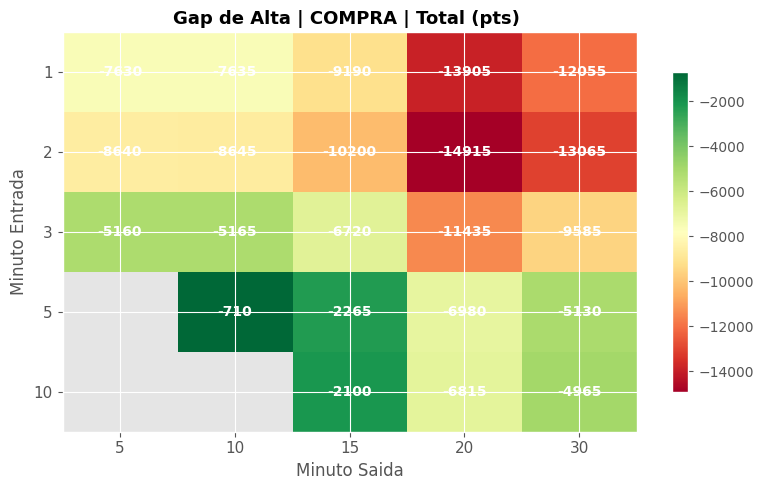

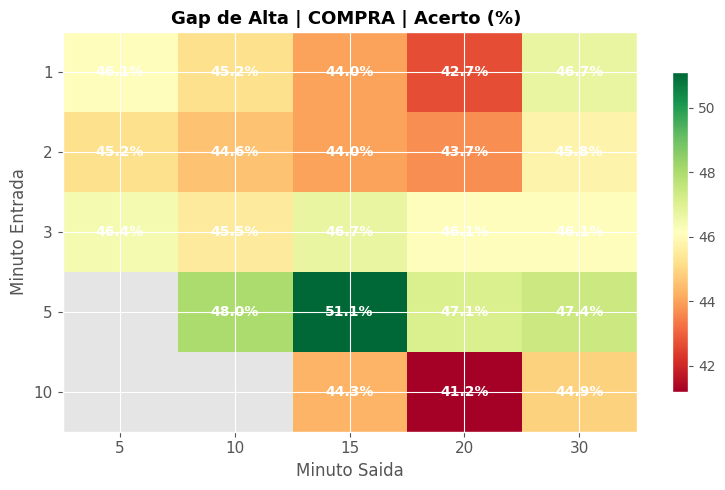

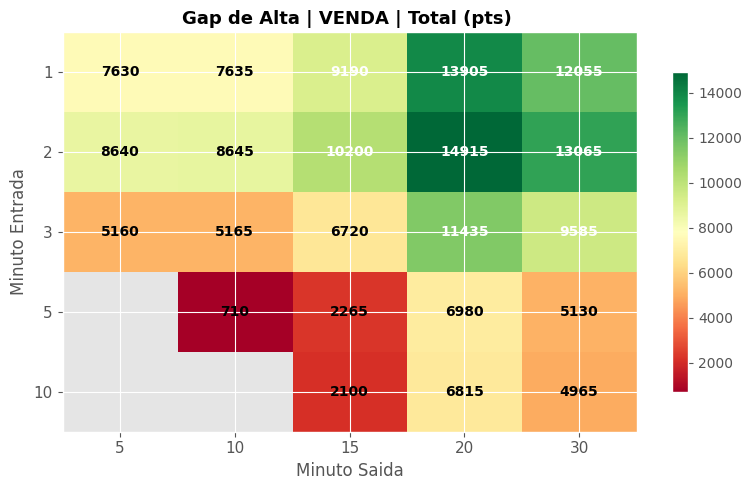

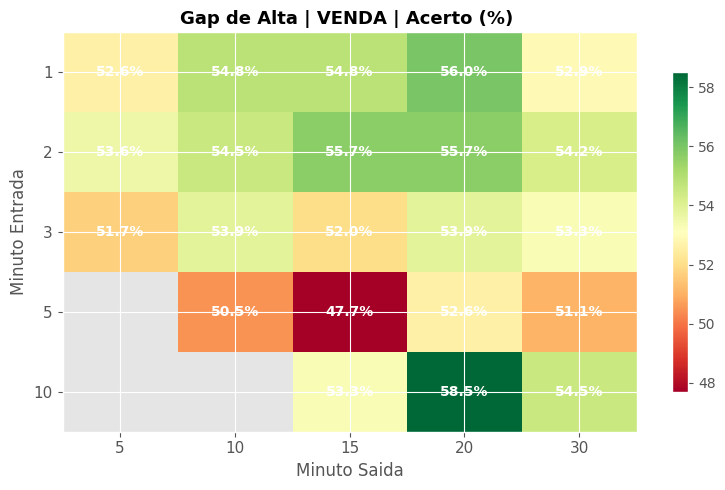


GAP DE BAIXA - TOP 10 CENARIOS (TEMPO PURO)


,tipo_gap,lado,entrada_min,saida_min,Trades,Acerto (%),Media (pts),Mediana (pts),Total (pts),Desvio (pts),Ganhos (pts),Perdas (pts),Fator Lucro,Expect/Trade (pts),Total (R$),Media (R$)
15,Gap de Baixa,compra,2,30,273.0,49.8,21.1,0.0,5760.0,365.9,40245.0,34485.0,1.167,21.1,1152.0,4.22
16,Gap de Baixa,venda,1,20,273.0,51.3,20.6,10.0,5620.0,358.2,38480.0,32860.0,1.171,20.6,1124.0,4.12
17,Gap de Baixa,venda,1,15,273.0,54.9,20.1,30.0,5475.0,335.0,36015.0,30540.0,1.179,20.1,1095.0,4.01
18,Gap de Baixa,venda,10,20,273.0,53.5,19.7,20.0,5370.0,198.4,23390.0,18020.0,1.298,19.7,1074.0,3.93
19,Gap de Baixa,venda,10,15,273.0,55.3,19.1,25.0,5225.0,137.1,17480.0,12255.0,1.426,19.1,1045.0,3.83
24,Gap de Baixa,venda,5,20,273.0,52.4,17.9,10.0,4900.0,255.5,28440.0,23540.0,1.208,17.9,980.0,3.59
25,Gap de Baixa,venda,5,15,273.0,54.6,17.4,25.0,4755.0,212.8,24710.0,19955.0,1.238,17.4,951.0,3.48
26,Gap de Baixa,compra,3,30,273.0,50.2,17.4,5.0,4740.0,360.0,38535.0,33795.0,1.140,17.4,948.0,3.47
27,Gap de Baixa,venda,3,20,273.0,51.3,10.3,10.0,2815.0,294.6,31480.0,28665.0,1.098,10.3,563.0,2.06
28,Gap de Baixa,venda,3,15,273.0,52.7,9.8,15.0,2670.0,250.7,27380.0,24710.0,1.108,9.8,534.0,1.96


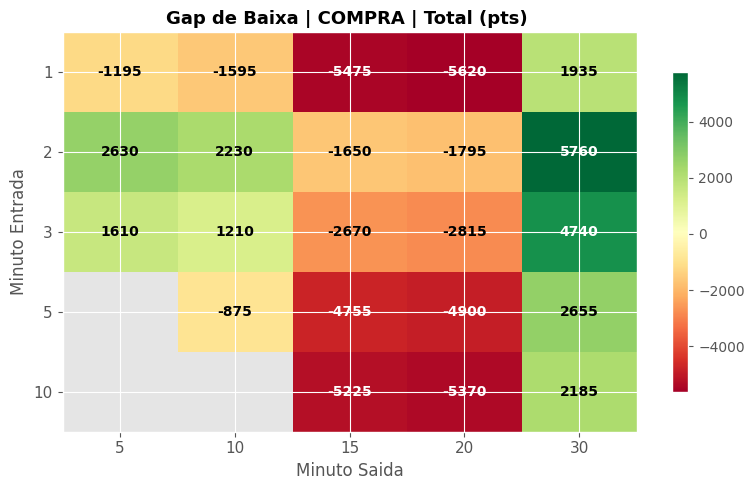

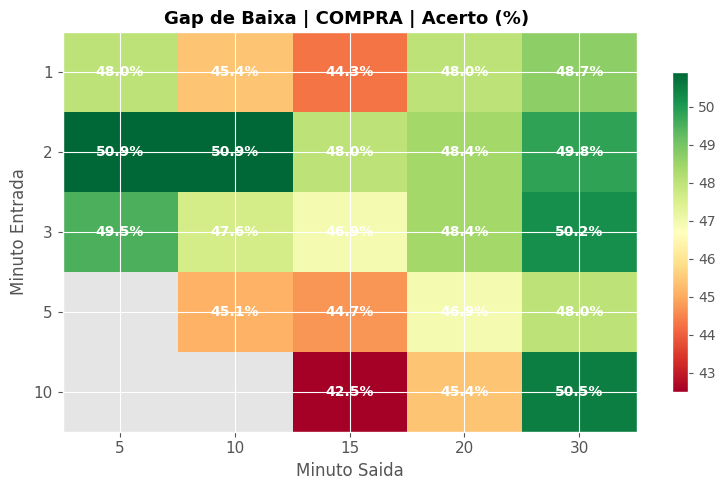

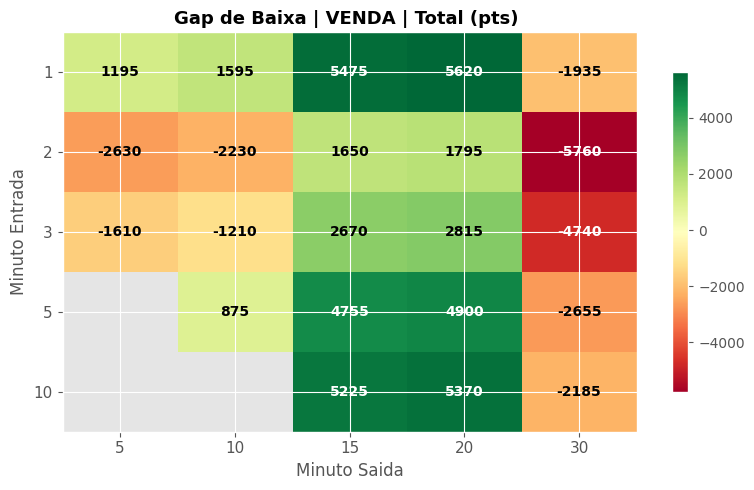

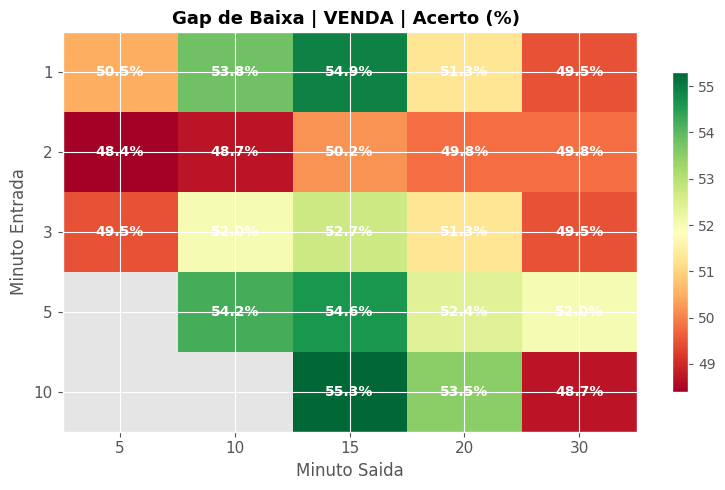


RESULTADO POR FAIXA DE GAP (melhor cenario por faixa)

── Gap de Alta ──


,faixa_gap,lado,entrada_min,saida_min,Trades,Acerto (%),Total (pts),Total (R$),Fator Lucro,Media (pts)
0,0 a 100,venda,1,20,30.0,66.7,6865.0,1373.0,5.062,228.8
1,100 a 200,venda,2,20,45.0,60.0,2320.0,464.0,1.795,51.6
2,200 a 300,venda,1,5,53.0,62.3,4095.0,819.0,2.365,77.3
3,300+,venda,2,30,195.0,52.3,6260.0,1252.0,1.251,32.1



── Gap de Baixa ──


,faixa_gap,lado,entrada_min,saida_min,Trades,Acerto (%),Total (pts),Total (R$),Fator Lucro,Media (pts)
0,0 a 100,compra,1,30,34.0,50.0,2605.0,521.0,1.705,76.6
1,100 a 200,venda,3,20,35.0,60.0,3420.0,684.0,2.572,97.7
2,200 a 300,compra,1,10,28.0,60.7,2390.0,478.0,2.144,85.4
3,300+,compra,3,30,176.0,53.4,7345.0,1469.0,1.378,41.7


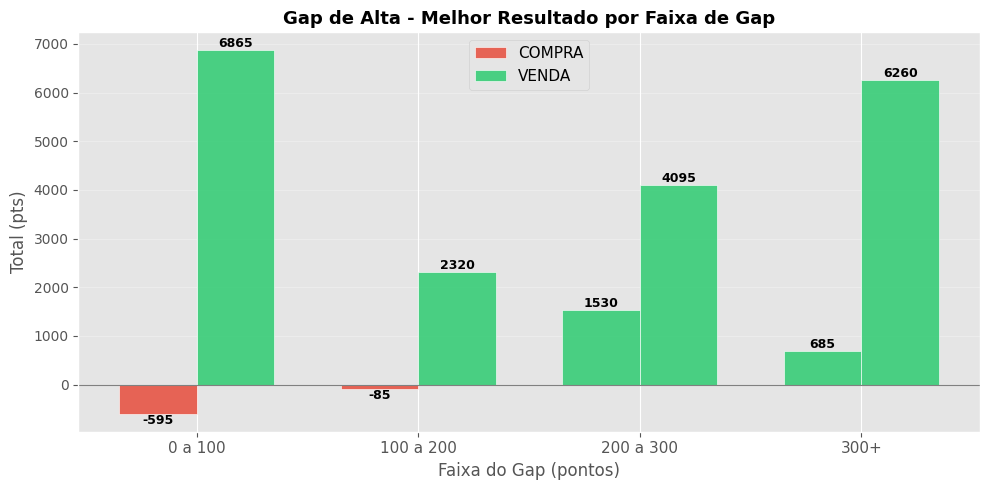

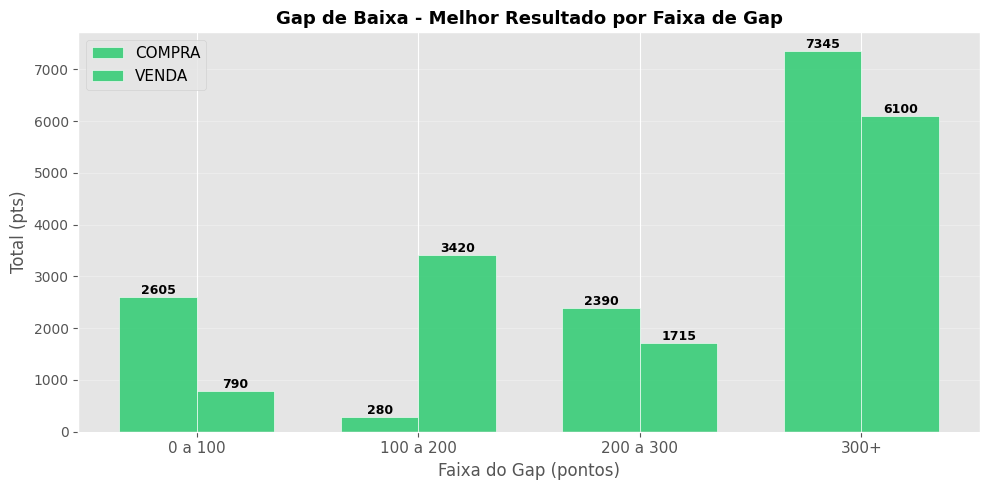


EQUITY CURVES - MELHORES CENARIOS

Gap de Alta - Melhor: VENDA E2 S20


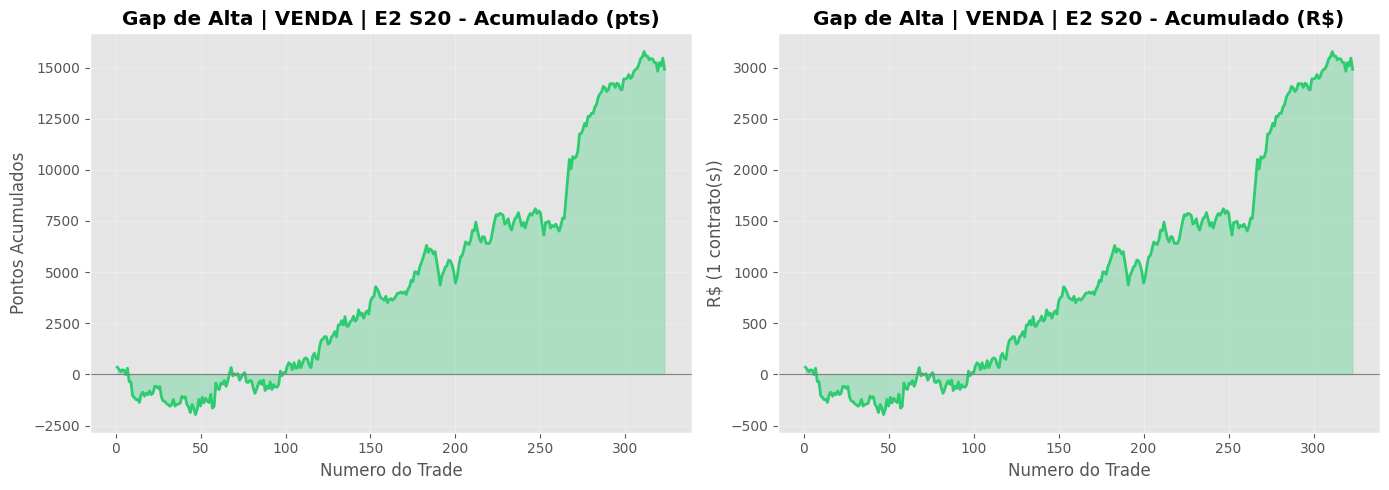

  323 trades | Acerto: 55.7% | Total: 14915 pts = R$ 2983.00

Gap de Baixa - Melhor: COMPRA E2 S30


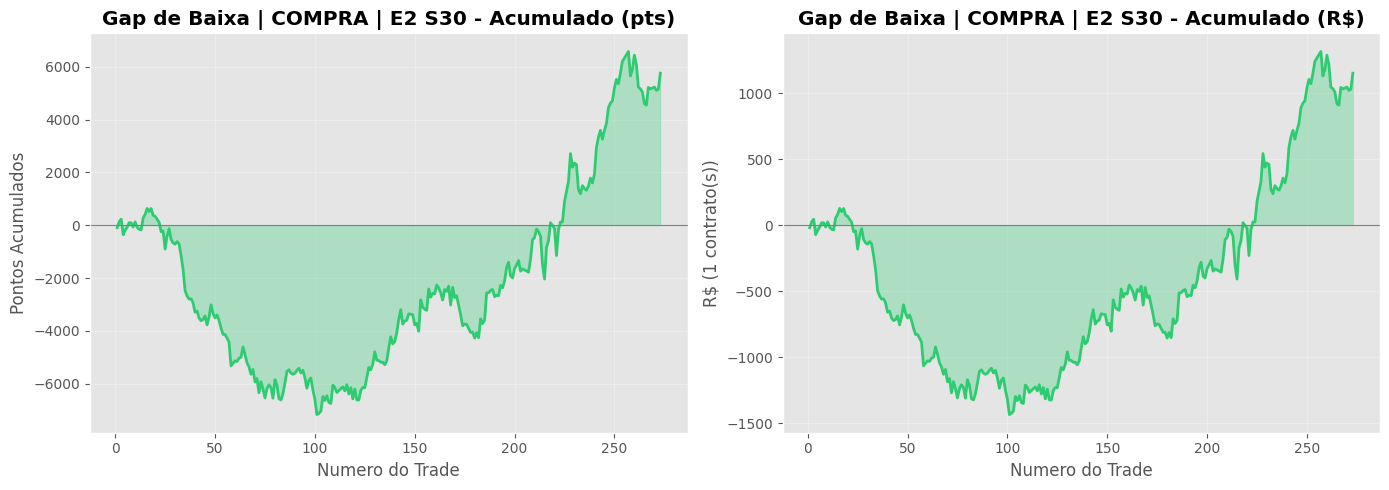

  273 trades | Acerto: 49.8% | Total: 5760 pts = R$ 1152.00

MODO COM RISCO (stop em % do gap + alvo em R)



── TOP 10 COM RISCO - GAP DE ALTA ──


,tipo_gap,lado,entrada_min,saida_min,stop_pct,alvo_rr,Trades,Acerto (%),Media (pts),Mediana (pts),Total (pts),Desvio (pts),Ganhos (pts),Perdas (pts),Fator Lucro,Expect/Trade (pts),Total (R$),Media (R$)
7,Gap de Alta,venda,2,15,30%,3.0R,323.0,38.7,22.3,-35.0,7216.5,201.4,27823.0,20606.5,1.350,22.3,1443.3,4.47
9,Gap de Alta,venda,2,20,30%,3.0R,323.0,35.0,21.7,-37.5,7002.5,216.3,28793.5,21791.0,1.321,21.7,1400.5,4.34
12,Gap de Alta,venda,2,30,30%,3.0R,323.0,35.6,21.0,-51.0,6792.5,240.7,32036.5,25244.0,1.269,21.0,1358.5,4.21
14,Gap de Alta,venda,2,30,20%,1.0R,323.0,64.1,20.5,29.0,6611.0,130.6,19481.0,12870.0,1.514,20.5,1322.2,4.09
15,Gap de Alta,venda,2,10,30%,1.0R,323.0,61.3,20.3,35.0,6557.5,144.3,21676.5,15119.0,1.434,20.3,1311.5,4.06
16,Gap de Alta,venda,2,15,30%,2.0R,323.0,42.1,19.1,-24.0,6161.5,185.7,26030.0,19868.5,1.310,19.1,1232.3,3.82
18,Gap de Alta,venda,2,15,30%,1.0R,323.0,61.9,18.3,34.5,5899.0,153.0,22301.0,16402.0,1.360,18.3,1179.8,3.65
19,Gap de Alta,venda,2,20,20%,1.0R,323.0,63.2,18.1,28.0,5843.0,120.7,18118.0,12275.0,1.476,18.1,1168.6,3.62
20,Gap de Alta,compra,1,5,20%,1.0R,323.0,65.6,18.0,34.0,5814.0,113.7,17416.0,11602.0,1.501,18.0,1162.8,3.60
21,Gap de Alta,venda,2,10,30%,3.0R,323.0,38.7,18.0,-27.0,5803.0,177.6,24503.5,18700.5,1.310,18.0,1160.6,3.59



── TOP 10 COM RISCO - GAP DE BAIXA ──


,tipo_gap,lado,entrada_min,saida_min,stop_pct,alvo_rr,Trades,Acerto (%),Media (pts),Mediana (pts),Total (pts),Desvio (pts),Ganhos (pts),Perdas (pts),Fator Lucro,Expect/Trade (pts),Total (R$),Media (R$)
0,Gap de Baixa,venda,1,5,20%,1.0R,273.0,71.4,35.7,39.0,9741.0,136.3,18782.0,9041.0,2.077,35.7,1948.2,7.14
1,Gap de Baixa,venda,1,10,20%,1.0R,273.0,71.4,34.9,40.0,9528.0,135.3,18952.0,9424.0,2.011,34.9,1905.6,6.98
2,Gap de Baixa,venda,1,30,20%,1.0R,273.0,70.7,33.8,40.0,9230.0,139.5,19191.0,9961.0,1.927,33.8,1846.0,6.76
3,Gap de Baixa,venda,1,15,20%,1.0R,273.0,71.1,33.6,39.0,9160.0,135.4,18727.0,9567.0,1.957,33.6,1832.0,6.71
4,Gap de Baixa,venda,1,20,20%,1.0R,273.0,70.3,33.3,39.0,9095.0,141.1,19081.0,9986.0,1.911,33.3,1819.0,6.66
5,Gap de Baixa,venda,1,20,50%,1.0R,273.0,60.1,28.2,40.0,7685.0,232.8,27820.0,20135.0,1.382,28.2,1537.0,5.63
6,Gap de Baixa,venda,1,15,50%,1.0R,273.0,61.9,27.2,45.0,7432.5,227.2,27185.0,19752.5,1.376,27.2,1486.5,5.45
8,Gap de Baixa,venda,1,30,50%,1.0R,273.0,60.1,25.8,47.5,7047.5,251.1,29462.5,22415.0,1.314,25.8,1409.5,5.16
10,Gap de Baixa,venda,1,5,50%,1.0R,273.0,58.6,25.1,37.5,6847.5,201.8,24390.0,17542.5,1.390,25.1,1369.5,5.02
11,Gap de Baixa,venda,1,10,50%,1.0R,273.0,60.4,25.0,40.0,6835.0,223.2,26077.5,19242.5,1.355,25.0,1367.0,5.01



DIAGNOSTICO - 10 PIORES CENARIOS (TEMPO PURO)


,tipo_gap,lado,entrada_min,saida_min,Trades,Acerto (%),Media (pts),Mediana (pts),Total (pts),Desvio (pts),Ganhos (pts),Perdas (pts),Fator Lucro,Expect/Trade (pts),Total (R$),Media (R$),Motivo
87,Gap de Alta,compra,2,20,323.0,43.7,-46.2,-55.0,-14915.0,287.6,29035.0,43950.0,0.661,-46.2,-2983.0,-9.24,taxa de acerto baixa; fator de lucro fraco
86,Gap de Alta,compra,1,20,323.0,42.7,-43.0,-40.0,-13905.0,345.1,36425.0,50330.0,0.724,-43.0,-2781.0,-8.61,taxa de acerto baixa; fator de lucro fraco
85,Gap de Alta,compra,2,30,323.0,45.8,-40.4,-40.0,-13065.0,345.3,38075.0,51140.0,0.745,-40.4,-2613.0,-8.09,fator de lucro fraco
84,Gap de Alta,compra,1,30,323.0,46.7,-37.3,-55.0,-12055.0,390.2,44810.0,56865.0,0.788,-37.3,-2411.0,-7.46,fator de lucro fraco
83,Gap de Alta,compra,3,20,323.0,46.1,-35.4,-30.0,-11435.0,272.0,28940.0,40375.0,0.717,-35.4,-2287.0,-7.08,fator de lucro fraco
82,Gap de Alta,compra,2,15,323.0,44.0,-31.6,-30.0,-10200.0,269.7,28635.0,38835.0,0.737,-31.6,-2040.0,-6.32,taxa de acerto baixa; fator de lucro fraco
81,Gap de Alta,compra,3,30,323.0,46.1,-29.7,-35.0,-9585.0,333.1,38025.0,47610.0,0.799,-29.7,-1917.0,-5.93,fator de lucro fraco
80,Gap de Alta,compra,1,15,323.0,44.0,-28.5,-30.0,-9190.0,322.3,35115.0,44305.0,0.793,-28.5,-1838.0,-5.69,taxa de acerto baixa; fator de lucro fraco
79,Gap de Alta,compra,2,10,323.0,44.6,-26.8,-35.0,-8645.0,237.7,26015.0,34660.0,0.751,-26.8,-1729.0,-5.35,taxa de acerto baixa; fator de lucro fraco
78,Gap de Alta,compra,2,5,323.0,45.2,-26.7,-25.0,-8640.0,201.9,20600.0,29240.0,0.705,-26.7,-1728.0,-5.35,fator de lucro fraco; janela muito curta



RESUMO: ONDE ENTRAR E ONDE SAIR?

Gap de Alta:
  COMPRA : E5 S10 -> -710 pts (R$ -142.00) | Acerto: 48.0% | Fator Lucro: 0.97 | 323 trades
  VENDA  : E2 S20 -> 14915 pts (R$ 2983.00) | Acerto: 55.7% | Fator Lucro: 1.51 | 323 trades

Gap de Baixa:
  COMPRA : E2 S30 -> 5760 pts (R$ 1152.00) | Acerto: 49.8% | Fator Lucro: 1.17 | 273 trades
  VENDA  : E1 S20 -> 5620 pts (R$ 1124.00) | Acerto: 51.3% | Fator Lucro: 1.17 | 273 trades



CSVs exportados em: C:\Users\rodrigo.silva\Pictures\UFG\DB FIN\outputs_gap_win


In [12]:
# ════════════════════════════════════════════════════════════════
# PARAMETROS EDITAVEIS - altere e reexecute esta celula
# ════════════════════════════════════════════════════════════════

ENTRADAS = [1, 2, 3, 5, 10]          # minutos apos abertura
SAIDAS = [5, 10, 15, 20, 30]         # minutos apos abertura
CUSTO_POR_TRADE = 0.0                # custo round trip em pontos
GAP_MINIMO = 0                       # filtro: gap minimo em pontos
GAP_MAXIMO = 999999                  # filtro: gap maximo em pontos
N_CONTRATOS = 1                      # quantidade de minicontratos
STOPS_PCT = [0.2, 0.3, 0.5]          # stop em % do gap (20%, 30%, 50%)
ALVOS_RR = [1.0, 1.5, 2.0, 3.0]     # alvo em multiplos de R

# ════════════════════════════════════════════════════════════════
# EXECUCAO (nao precisa alterar abaixo)
# ════════════════════════════════════════════════════════════════

intra_dict, gap_alta, gap_baixa = preparar_dados_simulacao(
    base_intraday, base_gap, GAP_MINIMO, GAP_MAXIMO
)

print(f'Dias com Gap de Alta: {len(gap_alta)}')
print(f'Dias com Gap de Baixa: {len(gap_baixa)}')
print(f'Custo por trade: {CUSTO_POR_TRADE} pts')
print(f'Contratos: {N_CONTRATOS} | Valor ponto: R$ {VALOR_PONTO_MINI}')
print(f'Filtro gap: {GAP_MINIMO} a {GAP_MAXIMO} pts')

# ── MODO TEMPO PURO ───────────────────────────────────────────
print('\n' + '='*70)
print('MODO TEMPO PURO (entra em X, sai em Y, sem stop/alvo)')
print('='*70)

todos_tp = []
for label, gdf in [('Gap de Alta', gap_alta), ('Gap de Baixa', gap_baixa)]:
    for lado in ['compra', 'venda']:
        df_t = simular_tempo_puro(gdf, intra_dict, lado, ENTRADAS, SAIDAS, CUSTO_POR_TRADE)
        if not df_t.empty:
            df_t['tipo_gap'] = label
            todos_tp.append(df_t)

if todos_tp:
    trades_tp = pd.concat(todos_tp, ignore_index=True)
else:
    trades_tp = pd.DataFrame()

# ── Resumo GERAL (todos os gaps juntos) ───────────────────────
resumo_geral = gerar_tabela_resumo(trades_tp, ['tipo_gap', 'lado', 'entrada_min', 'saida_min'], N_CONTRATOS)

# ── Resumo POR FAIXA de gap ──────────────────────────────────
resumo_faixa = gerar_tabela_resumo(trades_tp, ['tipo_gap', 'faixa_gap', 'lado', 'entrada_min', 'saida_min'], N_CONTRATOS)

# ═══════════════════════════════════════════════════
# TABELAS - GAP DE ALTA
# ═══════════════════════════════════════════════════
print('\n' + '='*70)
print('GAP DE ALTA - TOP 10 CENARIOS (TEMPO PURO)')
print('='*70)
top_alta = resumo_geral[resumo_geral['tipo_gap'] == 'Gap de Alta'].head(10)
display(top_alta)

# ── Matrizes heatmap - Gap de Alta ────────────────────────────
for lado in ['compra', 'venda']:
    plot_matriz_heatmap(resumo_geral, 'Gap de Alta', lado, 'Total (pts)', '', '{:.0f}')
    plot_matriz_heatmap(resumo_geral, 'Gap de Alta', lado, 'Acerto (%)', '', '{:.1f}%')

# ═══════════════════════════════════════════════════
# TABELAS - GAP DE BAIXA
# ═══════════════════════════════════════════════════
print('\n' + '='*70)
print('GAP DE BAIXA - TOP 10 CENARIOS (TEMPO PURO)')
print('='*70)
top_baixa = resumo_geral[resumo_geral['tipo_gap'] == 'Gap de Baixa'].head(10)
display(top_baixa)

for lado in ['compra', 'venda']:
    plot_matriz_heatmap(resumo_geral, 'Gap de Baixa', lado, 'Total (pts)', '', '{:.0f}')
    plot_matriz_heatmap(resumo_geral, 'Gap de Baixa', lado, 'Acerto (%)', '', '{:.1f}%')

# ═══════════════════════════════════════════════════
# TABELAS POR FAIXA DE GAP
# ═══════════════════════════════════════════════════
print('\n' + '='*70)
print('RESULTADO POR FAIXA DE GAP (melhor cenario por faixa)')
print('='*70)

for tipo in ['Gap de Alta', 'Gap de Baixa']:
    print(f'\n── {tipo} ──')
    sub_faixa = resumo_faixa[resumo_faixa['tipo_gap'] == tipo]
    if sub_faixa.empty:
        print('  Sem dados')
        continue
    # Melhor cenario por faixa
    melhor = sub_faixa.loc[sub_faixa.groupby('faixa_gap')['Total (pts)'].idxmax()]
    display(melhor[['faixa_gap', 'lado', 'entrada_min', 'saida_min',
                    'Trades', 'Acerto (%)', 'Total (pts)', 'Total (R$)',
                    'Fator Lucro', 'Media (pts)']].reset_index(drop=True))

# ── Grafico de barras por faixa ───────────────────────────────
for tipo in ['Gap de Alta', 'Gap de Baixa']:
    # Pega melhor cenario (entrada/saida) por faixa e lado
    sub = resumo_faixa[resumo_faixa['tipo_gap'] == tipo]
    if sub.empty:
        continue
    melhor_por_fl = sub.loc[sub.groupby(['faixa_gap', 'lado'])['Total (pts)'].idxmax()]
    plot_barras_por_faixa(melhor_por_fl, 'Total (pts)', f'{tipo} - Melhor Resultado por Faixa de Gap')

# ═══════════════════════════════════════════════════
# EQUITY CURVES (curva de capital acumulada)
# ═══════════════════════════════════════════════════
print('\n' + '='*70)
print('EQUITY CURVES - MELHORES CENARIOS')
print('='*70)

for tipo, df_gap_trades in [('Gap de Alta', trades_tp[trades_tp['tipo_gap']=='Gap de Alta']),
                             ('Gap de Baixa', trades_tp[trades_tp['tipo_gap']=='Gap de Baixa'])]:
    if df_gap_trades.empty:
        continue
    # Pega o melhor cenario
    melhor_row = resumo_geral[resumo_geral['tipo_gap'] == tipo].head(1)
    if melhor_row.empty:
        continue
    mr = melhor_row.iloc[0]
    print(f'\n{tipo} - Melhor: {mr["lado"].upper()} E{int(mr["entrada_min"])} S{int(mr["saida_min"])}')
    plot_evolucao_acumulada(df_gap_trades, tipo, mr['lado'],
                           int(mr['entrada_min']), int(mr['saida_min']), N_CONTRATOS)

# ═══════════════════════════════════════════════════
# MODO COM RISCO (stop + alvo)
# ═══════════════════════════════════════════════════
print('\n' + '='*70)
print('MODO COM RISCO (stop em % do gap + alvo em R)')
print('='*70)

todos_risco = []
for label, gdf in [('Gap de Alta', gap_alta), ('Gap de Baixa', gap_baixa)]:
    for lado in ['compra', 'venda']:
        df_r = simular_com_risco(gdf, intra_dict, lado, ENTRADAS, SAIDAS,
                                 STOPS_PCT, ALVOS_RR, CUSTO_POR_TRADE)
        if not df_r.empty:
            df_r['tipo_gap'] = label
            todos_risco.append(df_r)

if todos_risco:
    trades_risco = pd.concat(todos_risco, ignore_index=True)
    resumo_risco = gerar_tabela_resumo(
        trades_risco,
        ['tipo_gap', 'lado', 'entrada_min', 'saida_min', 'stop_pct', 'alvo_rr'],
        N_CONTRATOS
    )
    resumo_risco['stop_pct'] = (resumo_risco['stop_pct'] * 100).astype(int).astype(str) + '%'
    resumo_risco['alvo_rr'] = resumo_risco['alvo_rr'].apply(lambda x: f'{x:.1f}R')

    for tipo in ['Gap de Alta', 'Gap de Baixa']:
        print(f'\n── TOP 10 COM RISCO - {tipo.upper()} ──')
        top_r = resumo_risco[resumo_risco['tipo_gap'] == tipo].head(10)
        display(top_r)
else:
    trades_risco = pd.DataFrame()
    resumo_risco = pd.DataFrame()

# ═══════════════════════════════════════════════════
# DIAGNOSTICO
# ═══════════════════════════════════════════════════
print('\n' + '='*70)
print('DIAGNOSTICO - 10 PIORES CENARIOS (TEMPO PURO)')
print('='*70)
piores = resumo_geral.sort_values('Total (pts)', ascending=True).head(10).copy()

def diagnosticar(row):
    motivos = []
    if row['Acerto (%)'] < 45:
        motivos.append('taxa de acerto baixa')
    if row.get('Fator Lucro', 1) < 0.8:
        motivos.append('fator de lucro fraco')
    if row['Media (pts)'] < -50:
        motivos.append('prejuizo medio alto')
    saida = int(row['saida_min'])
    entrada = int(row['entrada_min'])
    if saida - entrada <= 3:
        motivos.append('janela muito curta')
    return '; '.join(motivos) if motivos else 'distribuicao desfavoravel'

piores['Motivo'] = piores.apply(diagnosticar, axis=1)
display(piores)

# ═══════════════════════════════════════════════════
# INTERPRETACAO FINAL
# ═══════════════════════════════════════════════════
print('\n' + '='*70)
print('RESUMO: ONDE ENTRAR E ONDE SAIR?')
print('='*70)

for tipo in ['Gap de Alta', 'Gap de Baixa']:
    print(f'\n{tipo}:')
    for lado in ['compra', 'venda']:
        sub = resumo_geral[(resumo_geral['tipo_gap'] == tipo) & (resumo_geral['lado'] == lado)]
        if sub.empty:
            continue
        best = sub.iloc[0]
        print(f'  {lado.upper():7s}: E{int(best["entrada_min"])} S{int(best["saida_min"])} '
              f'-> {best["Total (pts)"]:.0f} pts (R$ {best["Total (R$)"]:.2f}) | '
              f'Acerto: {best["Acerto (%)"]:.1f}% | Fator Lucro: {best["Fator Lucro"]:.2f} | '
              f'{int(best["Trades"])} trades')

# ═══════════════════════════════════════════════════
# EXPORTAR CSVs
# ═══════════════════════════════════════════════════
resumo_geral.to_csv(PASTA_SAIDA / 'simulador_tempo_puro_resumo.csv', index=False, encoding='utf-8-sig')
resumo_faixa.to_csv(PASTA_SAIDA / 'simulador_tempo_puro_por_faixa.csv', index=False, encoding='utf-8-sig')
if not resumo_risco.empty:
    resumo_risco.to_csv(PASTA_SAIDA / 'simulador_com_risco_resumo.csv', index=False, encoding='utf-8-sig')
piores.to_csv(PASTA_SAIDA / 'simulador_diagnostico_piores.csv', index=False, encoding='utf-8-sig')
print(f'\nCSVs exportados em: {PASTA_SAIDA.resolve()}')